# Spatial PRC1 → mapped population CTMC trajectory check

This notebook does **not** run SMC-ABC. It checks the spatial-to-population parameter map by:

1. running the spatial PRC1 Gillespie model,
2. recording spatial diagnostics on the observation grid,
3. mapping the spatial parameters to a population CTMC,
4. simulating the mapped CTMC,
5. comparing trajectories for \(N(t)\), \(n_1(t)\), and \(n_2(t)\),
6. comparing the flux into/out of \(n_2\).

The main map is now the **report-style capped-connectivity map** for \(k_{12}\):

\[
\widehat k_{12}=k_{12}^{\mathrm{site}}\widehat m,
\qquad
m_i(t)\le 3.
\]

For \(k_{21}\), the notebook uses the precise spatial detachment hazard:

\[
k_{21,j}^{\mathrm{spatial}}(t)=p_j.\texttt{detachment\_rate},
\]

i.e. the total rate for doubly bound PRC1 \(j\) to become singly bound at time \(t\). No divide by 2 is used.


In [1]:
# Self-contained copy of the uploaded spatial model files.
# This writes clean module names into ./spatial_model_modules and imports them from there.

from pathlib import Path
import sys

MODULE_DIR = Path('spatial_model_modules')
MODULE_DIR.mkdir(exist_ok=True)

module_sources = {'gillespie.py': 'import numpy as np\n\ndef default_timestep_function(state, time, dt):\n    """\n    default timestep function which just advances time by dt\n    """\n    return time + dt\n\ndef default_statistic_function(state, statistics):\n    """\n    default statistic function which records full state at each timepoint (very inefficient for large systems)\n    """\n    if statistics is None:\n        statistics = [state.copy()]\n    else:\n        statistics.append(state.copy())\n\ndef gillespie_step(state, time, rate_function, reaction_functions, \n                   timestep_function=default_timestep_function, \n                   max_timestep=np.inf):\n    """\n    gillespie step for a system with multiple agents and reactions. modifies state in place, returns time after step\n\n    :param state: state of the system at current time\n    :param time: current time of the system\n    :param rate_function: function(state) -> list of cumulative rates for each reaction for each agent\n        e.g. (r1 a1, r1 a2, ..., r2 a1, r2 a2, ...)\n    :param reaction_functions: list of functions(state, agent) which modify the state corresponding to each reaction\n    :param timestep_function: function(state, time, dt) -> new time after timestep, also modifies state if needed\n    :param num_agents: number of agents in the system\n    :return time: new time after gillespie step\n    """\n    # number of agents\n    num_agents = len(state) if len(state) > 0 else 1\n\n    # get cumulative rates and total rate\n    cumulative_rates = np.cumsum(rate_function(state))\n    total_rate = cumulative_rates[-1]\n\n\n    # determine next time something happens\n    # if total_rate <= 0:\n    #     print("Total rate <= 0!")\n    #     print(state)\n    #     print("cum rates:", cumulative_rates)\n    dt = np.random.exponential(1 / total_rate)\n    \n    # do timestep (if dt > max_timestep, nothing happens and we skip to the next timestep)\n    if dt > max_timestep:\n        return timestep_function(state, time, max_timestep)\n    new_time = timestep_function(state, time, dt)\n\n    # determine which reaction occurs and to which agent\n    random_value = np.random.uniform(0, 1) * total_rate\n    index = np.searchsorted(cumulative_rates, random_value)\n    # print("state:", state, "\\n\\nrates:", cumulative_rates, "\\nchoice:", index)\n    reaction_index = index // num_agents\n    agent = index % num_agents\n    reaction_function = reaction_functions[reaction_index]\n\n    # do reaction\n    reaction_function(state, agent)\n    return new_time\n\ndef run_gillespie(initial_state, end_time, rate_function, reaction_functions, \n                  statistic_function=default_statistic_function,\n                  timestep_function=default_timestep_function,\n                  max_timestep=np.inf, max_steps=np.inf):\n    """\n    run a gillespie simulation until end_time\n\n    :param initial_state: initial state of the system\n    :param end_time: time to end the simulation\n    :param rate_function: function(state) -> list of cumulative rates for each reaction for each agent\n        e.g. (r1 a1, r1 a2, ..., r2 a1, r2 a2, ...)\n    :param reaction_function: list of functions(state, agent) which modify the state corresponding to each reaction\n    :param statistic_function: function(state, statistic object, time) updates statistic object with current state.\n                                calls function(state, None) to initialize\n    :param timestep_function: function(state, time, dt) -> new time after timestep, also modifies state if needed\n    :param max_timestep: maximum timestep allowed before forcing a timestep\n    :return statistics: array of recorded statistics\n    :return times: array of times at which statistics were recorded\n    """\n    state = initial_state\n    time = 0.0\n    times = [time]\n    statistics = []\n    statistic_function(state, statistics, time)\n    steps = 1\n    while time < end_time and steps <= max_steps:\n        try:\n            time = gillespie_step(state, time, rate_function, reaction_functions, timestep_function, max_timestep)\n        except:\n            raise RuntimeError(str(state))\n        times.append(time)\n        statistic_function(state, statistics, time)\n        steps += 1\n    return statistics, np.array(times)', 'prc1.py': 'import numpy as np\n\nclass Prc1:\n    """""\n    Basic data class for PRC1 with some properties for readibility.\n    Represents a PRC1 molecule and stores the binding sites.\n    Binding sites are the integer indices if bound or None if unbound.\n    """\n    def __init__(self, state):\n        """\n        initialize PRC1 molecule\n        """\n        self.state = state  # so it can access state constants without having to pass them around\n        self.__binding_site_top = None\n        self.__binding_site_bottom = None\n\n        # closest neighbors that are doubly attached (for fast rate calculations)\n        self.closest_neighbor_left = None\n        self.closest_neighbor_right = None\n\n        # for avoiding recomputing detachment rates\n        self.__prev_binding_sites = (-1, -1)\n        self.__prev_detachment_rate = dict()\n\n    # GENERAL FUNCTIONS\n\n    def update_prc1_attributes(self, new_bottom_index, new_top_index):\n        """\n        updates prc1 with new indices,\n        re-sorts prc1 in prc1_set and doubly_attached_prc1,\n        updates top_taken_sites and bottom_taken_sites\n        """\n        state = self.state\n\n        # temporarily remove prc1 from state\n        if self.is_doubly_attached:\n            state.top_taken_sites.remove(self.__binding_site_top)\n            state.bottom_taken_sites.remove(self.__binding_site_bottom)\n            state.doubly_attached_prc1.remove(self)\n        else:\n            if self.top_head_is_attached:\n                state.top_attached_prc1.remove(self)\n                state.top_taken_sites.remove(self.__binding_site_top)\n            elif self.bottom_head_is_attached:\n                state.bottom_attached_prc1.remove(self)\n                state.bottom_taken_sites.remove(self.__binding_site_bottom)\n\n        # update binding sites\n        self.__binding_site_top = new_top_index\n        self.__binding_site_bottom = new_bottom_index\n        if self.top_head_is_attached:\n            state.top_taken_sites.add(self.binding_site_top)\n        if self.bottom_head_is_attached:\n            state.bottom_taken_sites.add(self.binding_site_bottom)\n\n        # add prc1 to sorted sets as necessary, also modify taken sites\n        if self.is_doubly_attached:\n            state.doubly_attached_prc1.add(self)\n        elif self.is_singly_attached:\n            if self.top_head_is_attached:\n                state.top_attached_prc1.add(self)\n                state.top_taken_sites.add(self.binding_site_top)\n            elif self.bottom_head_is_attached:\n                state.bottom_attached_prc1.add(self)\n                state.bottom_taken_sites.add(self.binding_site_bottom)\n\n    @property\n    def binding_site_top(self):\n        return self.__binding_site_top\n\n    @binding_site_top.setter\n    def binding_site_top(self, value):\n        self.update_prc1_attributes(self.__binding_site_bottom, value)\n\n    @property\n    def binding_site_bottom(self):\n        return self.__binding_site_bottom\n\n    @binding_site_bottom.setter\n    def binding_site_bottom(self, value):\n        self.update_prc1_attributes(value, self.__binding_site_top)\n\n    def set_closest_neighbors(self):\n        doubly_attached_prc1 = self.state.doubly_attached_prc1\n        if self in doubly_attached_prc1:\n            idx = doubly_attached_prc1.index(self)\n            self.closest_neighbor_left = doubly_attached_prc1[idx - 1] if idx > 0 else None\n            self.closest_neighbor_right = doubly_attached_prc1[idx + 1] if idx < len(doubly_attached_prc1) - 1 else None\n        else:\n            idx = doubly_attached_prc1.bisect_left(self)\n            self.closest_neighbor_left = doubly_attached_prc1[idx - 1] if idx > 0 else None\n            self.closest_neighbor_right = doubly_attached_prc1[idx] if idx < len(doubly_attached_prc1) else None\n\n    # sorts by top or bottom if they are both attached on the same side,\n    # otherwise sorts arbitrarily\n    def __lt__(self, other):\n        if self.is_unattached or other.is_unattached:\n            raise RuntimeError("error unbound comparing PRC", self, other)\n\n        if self.top_head_is_attached and other.top_head_is_attached:\n            return self.binding_site_top < other.binding_site_top\n        if self.bottom_head_is_attached and other.bottom_head_is_attached:\n            return self.binding_site_bottom < other.binding_site_bottom\n        return True\n\n    # ATTACHMENT RELATED PROPERTIES\n\n    @property\n    def bottom_head_is_attached(self):\n        return self.binding_site_bottom is not None\n\n    @property\n    def top_head_is_attached(self):\n        return self.binding_site_top is not None\n\n    @property\n    def is_doubly_attached(self):\n        return self.top_head_is_attached and self.bottom_head_is_attached\n\n    @property\n    def is_singly_attached(self):\n        return self.top_head_is_attached ^ self.bottom_head_is_attached\n\n    @property\n    def is_unattached(self):\n        return not (self.top_head_is_attached or self.bottom_head_is_attached)\n\n    # DISTANCE PROPERTIES\n    @property\n    def distance_between_heads(self):\n        return np.sqrt(self.horizontal_distance_between_heads**2 + self.vertical_distance_between_heads**2)\n\n    @property\n    def horizontal_distance_between_heads(self):\n        """always positive"""\n        top_index = self.binding_site_top\n        bottom_index = self.binding_site_bottom\n        offset = self.state.microtubule_offset\n        site_spacing = self.state.site_spacing\n        horizontal_displacement = (\n            top_index * site_spacing +\n            offset -\n            bottom_index * site_spacing\n        )\n        return np.abs(horizontal_displacement)\n\n    @property\n    def vertical_distance_between_heads(self):\n        return self.state.microtubule_separation\n\n    @property\n    def closest_index_on_other_side(self):\n        """returns closest binding site index (where the bottom site is on the left) on the opposite microtubule"""\n        offset = self.state.microtubule_offset\n        site_spacing = self.state.site_spacing\n\n        if self.is_doubly_attached:\n            print("Warning: closest index on other side requested for doubly attached PRC1")\n            return None\n\n        elif self.top_head_is_attached:\n            closest_bottom_index = np.floor(self.binding_site_top + offset / site_spacing).astype(int)\n            return closest_bottom_index\n\n        elif self.bottom_head_is_attached:\n            closest_top_index = np.ceil(self.binding_site_bottom - offset / site_spacing).astype(int)\n            return closest_top_index\n\n        else:\n            print("Warning: closest index on other side requested for unbound PRC1")\n            return None\n\n    @property\n    def current_energy(self):\n        return self.state.get_energy_between_indices(self.binding_site_bottom, self.binding_site_top)\n\n    # NEIGHBOR RELATED PROPERTIES\n    def __neighbor_opposite_index(self, neighbor, out_of_bounds):\n        """\n        finds the opposite head of neighbor,\n        returns out_of_bounds if no neighbor\n        """\n        if neighbor is None:\n            return out_of_bounds\n        elif neighbor.is_singly_attached:\n            raise RuntimeError("Neighbor opposite index requested for singly bound PRC1")\n        elif self.bottom_head_is_attached:\n            return neighbor.binding_site_top\n        elif self.top_head_is_attached:\n            return neighbor.binding_site_bottom\n        else:\n            raise RuntimeError("Neighbor opposite index requested for unbound PRC1")\n\n    @property\n    def left_neighbor_opposite_index(self):\n        return self.__neighbor_opposite_index(self.closest_neighbor_left, -1)\n\n    @property\n    def right_neighbor_opposite_index(self):\n        return self.__neighbor_opposite_index(self.closest_neighbor_right, self.state.num_sites)\n\n    # ATTACHMENT RATE PROPERTIES\n    def get_rates_and_range(self, total=False):\n        """\n        returns an array of cumulative attachment rates, as well as a list of indices it corresponds to\n        total=True returns just the total rate, to avoid extra computation.\n        these rates do not take into account taken sites, so are the rates to attempt to attach to each site\n        range is [left inclusive, right exclusive)\n        """\n        rates = self.state.precomputed_rates.copy()\n        zero_index = len(rates) // 2\n\n        left_index = self.left_neighbor_opposite_index + 1\n        right_index = self.right_neighbor_opposite_index\n        attachment_range = np.array([left_index, right_index])\n\n        closest_index = self.closest_index_on_other_side\n        relative_attachment_range = attachment_range - closest_index\n\n        left_range, right_range = relative_attachment_range + zero_index\n        if left_range < 0:\n            left_range = 0\n        if right_range > len(rates):\n            right_range = len(rates)\n        actual_range = np.array([left_range, right_range]) - zero_index + closest_index\n\n        # second-head attachment cooperativity only\n        if self.state.enable_second_head_attach_cooperativity:\n            if self.top_head_is_attached:\n                taken_indices = self.state.bottom_taken_sites.irange(\n                    actual_range[0] - 1, actual_range[1] + 1, inclusive=(True, False)\n                )\n            elif self.bottom_head_is_attached:\n                taken_indices = self.state.top_taken_sites.irange(\n                    actual_range[0] - 1, actual_range[1] + 1, inclusive=(True, False)\n                )\n            else:\n                taken_indices = []\n\n            cooperativity_coeff = np.exp(.5 * self.state.cooperativity_energy / self.state.k_B_T)\n            for index in taken_indices:\n                rate_index = index + zero_index - closest_index\n\n                if rate_index < 0 or rate_index >= len(rates):\n                    continue\n\n                rates[rate_index] = 0\n                if rate_index - 1 >= 0:\n                    rates[rate_index - 1] *= cooperativity_coeff\n                if rate_index + 1 < len(rates):\n                    rates[rate_index + 1] *= cooperativity_coeff\n\n        cumulative_rates = np.cumsum(rates[left_range:right_range])\n\n        if total:\n            if right_range == left_range or cumulative_rates.size == 0:\n                return 0\n            return cumulative_rates[-1]\n\n        return cumulative_rates, actual_range\n\n    @property\n    def double_attachment_rate(self):\n        if self.is_doubly_attached:\n            return 0\n        else:\n            return self.get_rates_and_range(total=True)\n\n    @property\n    def attachment_rate(self):\n        if self.is_doubly_attached:\n            return 0\n        elif self.is_singly_attached:\n            return self.double_attachment_rate\n        else:\n            print("Warning: PRC1 attachment rate requested for unbound PRC1")\n            return 0\n\n    # DETACHMENT RATE PROPERTIES\n    @property\n    def detachment_rate(self):\n        return self.bottom_detachment_rate + self.top_detachment_rate\n\n    @property\n    def top_detachment_rate(self):\n        return self.__get_detachment_rate(self.binding_site_bottom, None)\n\n    @property\n    def bottom_detachment_rate(self):\n        return self.__get_detachment_rate(None, self.binding_site_top)\n\n    def __get_detachment_rate(self, new_bottom_index, new_top_index):\n        base_double_detachment_rate = self.state.base_double_detachment_rate\n        singly_bound_detachment_rate = self.state.singly_bound_detachment_rate\n        k_B_T = self.state.k_B_T\n\n        current_energy = self.current_energy\n        new_energy = self.state.get_energy_between_indices(new_bottom_index, new_top_index)\n        delta_E = new_energy - current_energy\n        if self.is_doubly_attached:\n            return base_double_detachment_rate * np.exp(.5 * delta_E / k_B_T)\n        elif self.is_singly_attached:\n            return singly_bound_detachment_rate * np.exp(.5 * delta_E / k_B_T)\n\n    # HOPPING RATE PROPERTIES\n    def __get_hopping_rate(self, bottom_index, top_index):\n        """returns probability of hopping from current binding sites to (bottom_index, top_index)"""\n        if self.is_singly_attached:\n            return self.state.base_hopping_rate\n        if (bottom_index not in self.state.bottom_untaken_sites\n                or top_index not in self.state.top_untaken_sites):\n            return 0\n        base_hopping_rate = self.state.base_hopping_rate\n        current_energy = self.current_energy\n        new_energy = self.state.get_energy_between_indices(bottom_index, top_index) + self.state.cooperativity_energy\n        delta_E = new_energy - current_energy\n        return base_hopping_rate * np.exp(-.5 * delta_E / self.state.k_B_T)\n\n    @property\n    def total_bottom_hopping_rate(self):\n        return sum(self.bottom_hopping_rates)\n\n    @property\n    def total_top_hopping_rate(self):\n        return sum(self.top_hopping_rates)\n\n    @property\n    def bottom_hopping_rates(self):\n        """returns (left_hopping_rate, right_hopping_rate) for hopping to the left or right on the bottom microtubule"""\n        if not self.bottom_head_is_attached:\n            return (0, 0)\n        return (\n            self.__get_hopping_rate(self.binding_site_bottom - 1, self.binding_site_top),\n            self.__get_hopping_rate(self.binding_site_bottom + 1, self.binding_site_top)\n        )\n\n    @property\n    def top_hopping_rates(self):\n        """returns (left_hopping_rate, right_hopping_rate) for hopping to the left or right on the top microtubule"""\n        if not self.top_head_is_attached:\n            return (0, 0)\n        return (\n            self.__get_hopping_rate(self.binding_site_bottom, self.binding_site_top - 1),\n            self.__get_hopping_rate(self.binding_site_bottom, self.binding_site_top + 1)\n        )\n\n    # PRINTING\n    def __repr__(self):\n        return f"({self.binding_site_bottom}, {self.binding_site_top})"', 'prc1_state.py': 'import numpy as np\nfrom sortedcontainers import SortedSet\nfrom prc1 import Prc1\n\n\nclass SortedSetAndComplement(SortedSet):\n    """\n    Maintain a sorted set, its complement, and the set of untaken sites\n    adjacent to a taken site.\n    """\n    def __init__(self, universal_set):\n        self.universal_set = tuple(universal_set)\n        super().__init__()\n        self.complement = SortedSet(self.universal_set)\n        self.adjacencies = SortedSet()\n\n    def _refresh_local_adjacency(self, value):\n        for x in (value - 1, value, value + 1):\n            if x not in self.complement:\n                self.adjacencies.discard(x)\n                continue\n            if (x - 1 in self) or (x + 1 in self):\n                self.adjacencies.add(x)\n            else:\n                self.adjacencies.discard(x)\n\n    def add(self, value):\n        if value not in self.complement:\n            return\n        SortedSet.add(self, value)\n        self.complement.discard(value)\n        self._refresh_local_adjacency(value)\n\n    def discard(self, value):\n        if value not in self:\n            return\n        SortedSet.discard(self, value)\n        self.complement.add(value)\n        self._refresh_local_adjacency(value)\n\n    def remove(self, value):\n        if value not in self:\n            raise KeyError(value)\n        self.discard(value)\n\n\nclass State:\n    """\n    Maintains sorted lists of PRC1 objects and occupancy sets.\n    Handles updates when PRC1 bind, unbind, or hop.\n    """\n    def __init__(self, microtubule_length, site_spacing, microtubule_offset, spring_constant,\n                 rest_length, k_B_T, microtubule_separation, initial_binding_rate_per_site,\n                 singly_bound_detachment_rate, base_double_attachment_rate,\n                 base_double_detachment_rate, base_hopping_rate,\n                 cooperativity_energy=0,\n                 enable_initial_attach_cooperativity=False,\n                 enable_second_head_attach_cooperativity=False,\n                 enable_second_head_detach_cooperativity=False):\n\n        # fit params\n        self.singly_bound_detachment_rate = singly_bound_detachment_rate\n        self.base_double_attachment_rate = base_double_attachment_rate\n        self.base_double_detachment_rate = base_double_detachment_rate\n        self.cooperativity_energy = cooperativity_energy\n\n        # mode flags\n        self.enable_initial_attach_cooperativity = enable_initial_attach_cooperativity\n        self.enable_second_head_attach_cooperativity = enable_second_head_attach_cooperativity\n        self.enable_second_head_detach_cooperativity = enable_second_head_detach_cooperativity\n\n        # known base rates\n        self.base_hopping_rate = base_hopping_rate\n        self.initial_binding_rate_per_site = initial_binding_rate_per_site\n\n        # microtubule and site parameters\n        self.microtubule_length = microtubule_length\n        self.microtubule_separation = microtubule_separation\n        self.microtubule_offset = microtubule_offset\n\n        # constants\n        self.spring_constant = spring_constant\n        self.rest_length = rest_length\n        self.k_B_T = k_B_T\n\n        # site parameters\n        self.site_spacing = site_spacing\n        self.num_sites = int(microtubule_length / site_spacing) + 1\n\n        # occupancy sets\n        self.top_taken_sites = SortedSetAndComplement(range(self.num_sites))\n        self.bottom_taken_sites = SortedSetAndComplement(range(self.num_sites))\n\n        # PRC1 collections\n        self.doubly_attached_prc1 = SortedSet()\n        self.top_attached_prc1 = SortedSet()\n        self.bottom_attached_prc1 = SortedSet()\n\n        self.precompute_rates()\n\n        # debugging info\n        self.last_reaction = None\n        self.last_reaction_prc1 = None\n\n        # turn on only while debugging\n        self.debug_validate = False\n\n    # ------------------------------------------------------------------\n    # Initial attachment rates\n    # ------------------------------------------------------------------\n\n    @property\n    def initial_binding_rate(self):\n        return float(np.sum(self.cooperative_initial_binding_rates) +\n                     np.sum(self.uncooperative_initial_binding_rates))\n\n    @property\n    def cooperative_initial_binding_rates(self):\n        """\n        (bottom binding rate, top binding rate) based on valid adjacent untaken sites.\n        """\n        if not self.enable_initial_attach_cooperativity:\n            return np.array([0.0, 0.0], dtype=float)\n\n        cooperativity_rate = self.initial_binding_rate_per_site * np.exp(\n            0.5 * self.cooperativity_energy / self.k_B_T\n        )\n        return np.array([\n            len(self.bottom_adjacent_sites),\n            len(self.top_adjacent_sites),\n        ], dtype=float) * cooperativity_rate\n\n    @property\n    def uncooperative_initial_binding_rates(self):\n        """\n        (bottom binding rate, top binding rate) based on valid non-adjacent untaken sites.\n        """\n        n_bottom_untaken = len(self.bottom_untaken_sites)\n        n_top_untaken = len(self.top_untaken_sites)\n\n        if not self.enable_initial_attach_cooperativity:\n            return np.array([n_bottom_untaken, n_top_untaken], dtype=float) * self.initial_binding_rate_per_site\n\n        n_bottom_uncoop = n_bottom_untaken - len(self.bottom_adjacent_sites)\n        n_top_uncoop = n_top_untaken - len(self.top_adjacent_sites)\n\n        return np.array([n_bottom_uncoop, n_top_uncoop], dtype=float) * self.initial_binding_rate_per_site\n\n    # ------------------------------------------------------------------\n    # Taken / untaken site helpers\n    # ------------------------------------------------------------------\n\n    @property\n    def top_untaken_sites(self):\n        return self.top_taken_sites.complement\n\n    @property\n    def bottom_untaken_sites(self):\n        return self.bottom_taken_sites.complement\n\n    @property\n    def top_adjacent_sites(self):\n        return self.top_taken_sites.adjacencies\n\n    @property\n    def bottom_adjacent_sites(self):\n        return self.bottom_taken_sites.adjacencies\n\n    def _bottom_nonadjacent_untaken_sites(self):\n        return [s for s in self.bottom_untaken_sites if s not in self.bottom_adjacent_sites]\n\n    def _top_nonadjacent_untaken_sites(self):\n        return [s for s in self.top_untaken_sites if s not in self.top_adjacent_sites]\n\n    # ------------------------------------------------------------------\n    # Basic operations\n    # ------------------------------------------------------------------\n\n    def clear(self):\n        self.top_taken_sites = SortedSetAndComplement(range(self.num_sites))\n        self.bottom_taken_sites = SortedSetAndComplement(range(self.num_sites))\n        self.top_attached_prc1.clear()\n        self.bottom_attached_prc1.clear()\n        self.doubly_attached_prc1.clear()\n\n    @property\n    def num_prc1(self):\n        return (\n            len(self.doubly_attached_prc1)\n            + len(self.top_attached_prc1)\n            + len(self.bottom_attached_prc1)\n        )\n\n    def get_prc1(self, index):\n        if index < len(self.doubly_attached_prc1):\n            return self.doubly_attached_prc1[index]\n        index -= len(self.doubly_attached_prc1)\n\n        if index < len(self.top_attached_prc1):\n            return self.top_attached_prc1[index]\n        index -= len(self.top_attached_prc1)\n\n        if index < len(self.bottom_attached_prc1):\n            return self.bottom_attached_prc1[index]\n\n        raise IndexError("PRC1 index out of range")\n\n    def __getitem__(self, index):\n        return self.get_prc1(index)\n\n    def __len__(self):\n        return (\n            len(self.doubly_attached_prc1)\n            + len(self.top_attached_prc1)\n            + len(self.bottom_attached_prc1)\n        )\n\n    def __iter__(self):\n        for prc1 in self.doubly_attached_prc1:\n            yield prc1\n        for prc1 in self.top_attached_prc1:\n            yield prc1\n        for prc1 in self.bottom_attached_prc1:\n            yield prc1\n\n    # ------------------------------------------------------------------\n    # Validation\n    # ------------------------------------------------------------------\n\n    def validate_state(self):\n        top_sites = []\n        bottom_sites = []\n\n        for prc1 in self.doubly_attached_prc1:\n            if prc1.binding_site_top is None or prc1.binding_site_bottom is None:\n                raise RuntimeError(f"Malformed doubly attached PRC1: {prc1}")\n            top_sites.append(prc1.binding_site_top)\n            bottom_sites.append(prc1.binding_site_bottom)\n\n        for prc1 in self.top_attached_prc1:\n            if prc1.binding_site_top is None or prc1.binding_site_bottom is not None:\n                raise RuntimeError(f"Malformed top-attached PRC1: {prc1}")\n            top_sites.append(prc1.binding_site_top)\n\n        for prc1 in self.bottom_attached_prc1:\n            if prc1.binding_site_bottom is None or prc1.binding_site_top is not None:\n                raise RuntimeError(f"Malformed bottom-attached PRC1: {prc1}")\n            bottom_sites.append(prc1.binding_site_bottom)\n\n        if len(top_sites) != len(set(top_sites)):\n            raise RuntimeError(f"Duplicate top occupancy: {top_sites}")\n        if len(bottom_sites) != len(set(bottom_sites)):\n            raise RuntimeError(f"Duplicate bottom occupancy: {bottom_sites}")\n\n        if set(top_sites) != set(self.top_taken_sites):\n            raise RuntimeError("Mismatch between PRC1 top sites and top_taken_sites")\n        if set(bottom_sites) != set(self.bottom_taken_sites):\n            raise RuntimeError("Mismatch between PRC1 bottom sites and bottom_taken_sites")\n\n    def _maybe_validate(self):\n        if self.debug_validate:\n            self.validate_state()\n\n    # ------------------------------------------------------------------\n    # State modification functions\n    # ------------------------------------------------------------------\n\n    def single_attach_prc1(self):\n        if not self.enable_initial_attach_cooperativity:\n            bottom_candidates = list(self.bottom_untaken_sites)\n            top_candidates = list(self.top_untaken_sites)\n\n            bottom_rate = len(bottom_candidates) * self.initial_binding_rate_per_site\n            top_rate = len(top_candidates) * self.initial_binding_rate_per_site\n            total_rate = bottom_rate + top_rate\n\n            if total_rate <= 0:\n                raise RuntimeError("single_attach_prc1 called with no available sites")\n\n            probabilities = np.array([bottom_rate, top_rate], dtype=float) / total_rate\n            attachment_head_bottom = bool(np.random.choice([True, False], p=probabilities))\n\n            if attachment_head_bottom:\n                site = int(np.random.choice(bottom_candidates))\n            else:\n                site = int(np.random.choice(top_candidates))\n\n        else:\n            bottom_coop_candidates = list(self.bottom_adjacent_sites)\n            top_coop_candidates = list(self.top_adjacent_sites)\n            bottom_uncoop_candidates = self._bottom_nonadjacent_untaken_sites()\n            top_uncoop_candidates = self._top_nonadjacent_untaken_sites()\n\n            coop_rate_per_site = self.initial_binding_rate_per_site * np.exp(\n                0.5 * self.cooperativity_energy / self.k_B_T\n            )\n\n            bottom_rate_coop = len(bottom_coop_candidates) * coop_rate_per_site\n            top_rate_coop = len(top_coop_candidates) * coop_rate_per_site\n            bottom_rate_uncoop = len(bottom_uncoop_candidates) * self.initial_binding_rate_per_site\n            top_rate_uncoop = len(top_uncoop_candidates) * self.initial_binding_rate_per_site\n\n            total_rate = (\n                bottom_rate_coop + top_rate_coop\n                + bottom_rate_uncoop + top_rate_uncoop\n            )\n\n            if total_rate <= 0:\n                raise RuntimeError("single_attach_prc1 called with no valid sites")\n\n            probabilities = np.array(\n                [bottom_rate_coop, top_rate_coop, bottom_rate_uncoop, top_rate_uncoop],\n                dtype=float\n            ) / total_rate\n\n            choice = int(np.random.choice([0, 1, 2, 3], p=probabilities))\n\n            if choice == 0:\n                attachment_head_bottom = True\n                site = int(np.random.choice(bottom_coop_candidates))\n            elif choice == 1:\n                attachment_head_bottom = False\n                site = int(np.random.choice(top_coop_candidates))\n            elif choice == 2:\n                attachment_head_bottom = True\n                site = int(np.random.choice(bottom_uncoop_candidates))\n            else:\n                attachment_head_bottom = False\n                site = int(np.random.choice(top_uncoop_candidates))\n\n        prc1 = Prc1(self)\n        if attachment_head_bottom:\n            prc1.binding_site_bottom = site\n        else:\n            prc1.binding_site_top = site\n\n        prc1.set_closest_neighbors()\n        self.last_reaction = "single attach"\n        self.last_reaction_prc1 = str(prc1)\n        self._maybe_validate()\n\n    def double_attach_prc1(self, prc1_index):\n        prc1 = self.get_prc1(prc1_index)\n\n        precomputed_rates, (left_bound, right_bound) = prc1.get_rates_and_range()\n        self.last_reaction = "double attach"\n        self.last_reaction_prc1 = str(prc1)\n\n        if len(precomputed_rates) == 0:\n            raise RuntimeError("tried to double attach prc1 with 0 attachment rate")\n\n        total_rate = precomputed_rates[-1]\n        random_value = np.random.uniform(0, total_rate)\n        relative_attachment_index = np.searchsorted(precomputed_rates, random_value)\n        attachment_index = relative_attachment_index + left_bound\n\n        if attachment_index <= prc1.left_neighbor_opposite_index:\n            raise RuntimeError("LEFT BOUND WRONG", self.last_reaction_prc1, self)\n        elif right_bound > prc1.right_neighbor_opposite_index:\n            raise RuntimeError("RIGHT BOUND WRONG", self.last_reaction_prc1, self)\n\n        if prc1.bottom_head_is_attached:\n            if attachment_index in self.top_taken_sites:\n                return\n            prc1.binding_site_top = attachment_index\n\n        elif prc1.top_head_is_attached:\n            if attachment_index in self.bottom_taken_sites:\n                return\n            prc1.binding_site_bottom = attachment_index\n\n        else:\n            raise RuntimeError("tried to double attach non-attached PRC1")\n\n        left_neighbor = prc1.closest_neighbor_left\n        right_neighbor = prc1.closest_neighbor_right\n\n        if left_neighbor is not None:\n            left_neighbor.closest_neighbor_right = prc1\n        if right_neighbor is not None:\n            right_neighbor.closest_neighbor_left = prc1\n\n        self.set_neighbors_between_prc1(left_neighbor, prc1)\n        self.set_neighbors_between_prc1(prc1, right_neighbor)\n        self._maybe_validate()\n\n    def detach_prc1(self, prc1_index):\n        prc1 = self.get_prc1(prc1_index)\n\n        if prc1.is_singly_attached:\n            self.last_reaction = "single detach"\n            self.last_reaction_prc1 = str(prc1)\n\n            if prc1.bottom_head_is_attached:\n                prc1.binding_site_bottom = None\n            else:\n                prc1.binding_site_top = None\n\n        else:\n            self.last_reaction = "double detach"\n            self.last_reaction_prc1 = str(prc1)\n\n            bottom_rate = prc1.top_detachment_rate\n            top_rate = prc1.bottom_detachment_rate\n            probabilities = np.array([bottom_rate, top_rate], dtype=float) / (bottom_rate + top_rate)\n            detach_bottom_head = np.random.choice([True, False], p=probabilities)\n\n            if detach_bottom_head:\n                prc1.binding_site_bottom = None\n            else:\n                prc1.binding_site_top = None\n\n            left_neighbor = prc1.closest_neighbor_left\n            right_neighbor = prc1.closest_neighbor_right\n\n            if left_neighbor is not None:\n                left_neighbor.closest_neighbor_right = right_neighbor\n            if right_neighbor is not None:\n                right_neighbor.closest_neighbor_left = left_neighbor\n\n            self.set_neighbors_between_prc1(left_neighbor, right_neighbor)\n\n        self._maybe_validate()\n\n    def hop_top(self, prc1_index):\n        prc1 = self.get_prc1(prc1_index)\n        if not prc1.top_head_is_attached:\n            raise RuntimeError("tried to hop top head of PRC1 with unattached top head")\n\n        self.last_reaction = "hop top"\n        self.last_reaction_prc1 = str(prc1)\n\n        hopping_rates = np.asarray(prc1.top_hopping_rates, dtype=float)\n        total = hopping_rates.sum()\n        if total <= 0:\n            raise RuntimeError("hop_top called with zero total hopping rate")\n\n        hopping_probabilities = hopping_rates / total\n        step = int(np.random.choice([-1, 1], p=hopping_probabilities))\n        new_site = prc1.binding_site_top + step\n\n        if new_site not in self.top_untaken_sites:\n            raise RuntimeError("tried to hop top head to invalid or occupied site")\n\n        prc1.binding_site_top = new_site\n        self._maybe_validate()\n\n    def hop_bottom(self, prc1_index):\n        prc1 = self.get_prc1(prc1_index)\n        if not prc1.bottom_head_is_attached:\n            raise RuntimeError("tried to hop bottom head of PRC1 with unattached bottom head")\n\n        self.last_reaction = "hop bottom"\n        self.last_reaction_prc1 = str(prc1)\n\n        hopping_rates = np.asarray(prc1.bottom_hopping_rates, dtype=float)\n        total = hopping_rates.sum()\n        if total <= 0:\n            raise RuntimeError("hop_bottom called with zero total hopping rate")\n\n        hopping_probabilities = hopping_rates / total\n        step = int(np.random.choice([-1, 1], p=hopping_probabilities))\n        new_site = prc1.binding_site_bottom + step\n\n        if new_site not in self.bottom_untaken_sites:\n            raise RuntimeError("tried to hop bottom head to invalid or occupied site")\n\n        prc1.binding_site_bottom = new_site\n        self._maybe_validate()\n\n    def set_neighbors_between_prc1(self, left_prc1, right_prc1):\n        if left_prc1 is not None and left_prc1.is_unattached:\n            raise RuntimeError("LEFT NEIGHBOR UNATTACHED")\n        if right_prc1 is not None and right_prc1.is_unattached:\n            raise RuntimeError("RIGHT NEIGHBOR UNATTACHED")\n\n        def set_neighbors_for_set(prc1_set):\n            left_index = 0 if left_prc1 is None else prc1_set.bisect_left(left_prc1)\n            right_index = len(prc1_set) if right_prc1 is None else prc1_set.bisect_right(right_prc1)\n            for prc1 in prc1_set[left_index:right_index]:\n                prc1.closest_neighbor_left = left_prc1\n                prc1.closest_neighbor_right = right_prc1\n\n        set_neighbors_for_set(self.bottom_attached_prc1)\n        set_neighbors_for_set(self.top_attached_prc1)\n\n    # ------------------------------------------------------------------\n    # Precomputed attachment rates\n    # ------------------------------------------------------------------\n\n    def precompute_rates(self, divisions=1):\n        num_sites_to_compute = self.num_sites * 2\n        self.__precomputed_division_size = self.site_spacing / divisions\n        self.__precomputed_division_num = divisions\n\n        offset = np.linspace(0, self.site_spacing, divisions, endpoint=False)\n        base_horizontal_distances = np.arange(\n            -(num_sites_to_compute // 2),\n            (num_sites_to_compute // 2) + 1\n        ) * self.site_spacing\n\n        horizontal_distances = base_horizontal_distances[:, np.newaxis] + offset[np.newaxis, :]\n        distances = np.sqrt(horizontal_distances**2 + self.microtubule_separation**2)\n        E = 0.5 * self.spring_constant * np.maximum(distances - self.rest_length, 0)**2\n\n        self.__precomputed_rates = self.base_double_attachment_rate * np.exp(-0.5 * E / self.k_B_T)\n        self.__precomputed_cumulative_rates = np.cumsum(self.__precomputed_rates, axis=0)\n\n    @property\n    def precomputed_cumulative_rates(self):\n        index = int(self.microtubule_offset // self.__precomputed_division_size) % self.__precomputed_division_num\n        return self.__precomputed_cumulative_rates[:, index]\n\n    @property\n    def precomputed_rates(self):\n        index = int(self.microtubule_offset // self.__precomputed_division_size) % self.__precomputed_division_num\n        return self.__precomputed_rates[:, index]\n\n    # ------------------------------------------------------------------\n    # Printing and misc\n    # ------------------------------------------------------------------\n\n    def __repr__(self):\n        return (\n            f"State(\\n"\n            f"doubly_attached_prc1 = {self.doubly_attached_prc1}\\n"\n            f"top_attached_prc1 = {self.top_attached_prc1}\\n"\n            f"bottom_attached_prc1 = {self.bottom_attached_prc1}\\n"\n            f"top_taken_sites = {self.top_taken_sites}\\n"\n            f"bottom_taken_sites = {self.bottom_taken_sites}\\n"\n            f")"\n        )\n\n    def get_distance_between_indices(self, bottom_index, top_index):\n        offset = self.microtubule_offset\n        site_spacing = self.site_spacing\n        horizontal_displacement = (top_index * site_spacing + offset - bottom_index * site_spacing)\n        vertical_displacement = self.microtubule_separation\n        return np.sqrt(horizontal_displacement**2 + vertical_displacement**2)\n\n    def get_energy_between_indices(self, bottom_index, top_index):\n        if self.enable_second_head_detach_cooperativity:\n            num_neighbors = [\n                (top_index is not None) and (top_index - 1 in self.top_taken_sites),\n                (top_index is not None) and (top_index + 1 in self.top_taken_sites),\n                (bottom_index is not None) and (bottom_index - 1 in self.bottom_taken_sites),\n                (bottom_index is not None) and (bottom_index + 1 in self.bottom_taken_sites),\n            ].count(True)\n            E = -self.cooperativity_energy * num_neighbors\n        else:\n            E = 0.0\n\n        if top_index is None or bottom_index is None:\n            return E\n\n        distance = self.get_distance_between_indices(bottom_index, top_index)\n        E += 0.5 * self.spring_constant * np.maximum(distance - self.rest_length, 0)**2\n        return E', 'run_gillespie.py': 'from gillespie import run_gillespie, gillespie_step\nfrom prc1_state import State\nimport numpy as np\n\n\ndef run_gillespie_prc1(initial_binding_rate_per_site, singly_bound_detachment_rate,\n                       base_double_attachment_rate, base_double_detachment_rate,\n                       end_time=1, cooperativity_energy=0,\n                       enable_initial_attach_cooperativity=False,\n                       enable_second_head_attach_cooperativity=False,\n                       enable_second_head_detach_cooperativity=False,\n                       enable_hopping=True, max_steps=np.inf):\n\n    # define (initial) state params\n    microtubule_length = 5000\n    site_spacing = 8\n    microtubule_offset = 0\n    spring_constant = 2\n    rest_length = 32\n    k_B_T = 4.1\n    microtubule_separation = 30\n    base_hopping_rate = 1\n\n    params = (\n        microtubule_length, site_spacing, microtubule_offset, spring_constant,\n        rest_length, k_B_T, microtubule_separation, initial_binding_rate_per_site,\n        singly_bound_detachment_rate, base_double_attachment_rate,\n        base_double_detachment_rate, base_hopping_rate,\n        cooperativity_energy,\n        enable_initial_attach_cooperativity,\n        enable_second_head_attach_cooperativity,\n        enable_second_head_detach_cooperativity\n    )\n\n    initial_state = State(*params)\n\n    # returns (single attach rates, double attach rates, detach rates, hop bottom rates, hop top rates)\n    def rate_function(state):\n        initial_binding_rate = state.initial_binding_rate\n        if len(state) == 0:\n            return [initial_binding_rate, 0, 0, 0, 0]\n\n        rates = [initial_binding_rate] + [0] * (len(state) - 1)\n\n        for prc1 in state:\n            rates.append(prc1.double_attachment_rate)\n        for prc1 in state:\n            rates.append(prc1.detachment_rate)\n\n        if enable_hopping:\n            for prc1 in state:\n                rates.append(prc1.total_bottom_hopping_rate)\n            for prc1 in state:\n                rates.append(prc1.total_top_hopping_rate)\n\n        return rates\n\n    def single_attach_func(state, index):\n        state.single_attach_prc1()\n\n    def double_attach_func(state, index):\n        state.double_attach_prc1(index)\n\n    def detach_func(state, index):\n        state.detach_prc1(index)\n\n    def hop_bottom_func(state, index):\n        state.hop_bottom(index)\n\n    def hop_top_func(state, index):\n        state.hop_top(index)\n\n    if enable_hopping:\n        reaction_functions = [\n            single_attach_func, double_attach_func, detach_func,\n            hop_bottom_func, hop_top_func\n        ]\n    else:\n        reaction_functions = [\n            single_attach_func, double_attach_func, detach_func\n        ]\n\n    def statistic_function(state, stat_list, time):\n        if stat_list is None:\n            stat_list = []\n        stat_list.append(len(state))\n\n    def timestep_function(state, time, dt):\n        return time + dt\n\n    max_timestep = np.inf\n\n    return run_gillespie(\n        initial_state, end_time, rate_function, reaction_functions,\n        statistic_function, timestep_function, max_timestep, max_steps\n    )\n\n\ndef run_gillespie_prc1_on_grid(initial_binding_rate_per_site, singly_bound_detachment_rate,\n                               base_double_attachment_rate, base_double_detachment_rate,\n                               times_obs, cooperativity_energy=0,\n                               enable_initial_attach_cooperativity=False,\n                               enable_second_head_attach_cooperativity=False,\n                               enable_second_head_detach_cooperativity=False,\n                               enable_hopping=True, max_steps=200_000):\n    """\n    Run the spatial PRC1 Gillespie model and sample y(t)=len(state)\n    on times_obs using right-continuous sampling.\n    """\n    times_obs = np.asarray(times_obs, dtype=float)\n    if times_obs.ndim != 1:\n        raise ValueError("times_obs must be a 1D array")\n    if len(times_obs) == 0:\n        return np.zeros(0, dtype=float)\n    if np.any(np.diff(times_obs) < 0):\n        raise ValueError("times_obs must be sorted nondecreasing")\n\n    statistics, times = run_gillespie_prc1(\n        initial_binding_rate_per_site,\n        singly_bound_detachment_rate,\n        base_double_attachment_rate,\n        base_double_detachment_rate,\n        end_time=float(times_obs[-1]),\n        cooperativity_energy=cooperativity_energy,\n        enable_initial_attach_cooperativity=enable_initial_attach_cooperativity,\n        enable_second_head_attach_cooperativity=enable_second_head_attach_cooperativity,\n        enable_second_head_detach_cooperativity=enable_second_head_detach_cooperativity,\n        enable_hopping=enable_hopping,\n        max_steps=max_steps,\n    )\n\n    stats_obs = []\n    for time in times_obs:\n        if time < times[0]:\n            stats_obs.append(0)\n        else:\n            idx = np.searchsorted(times, time, side="right") - 1\n            stats_obs.append(statistics[idx])\n\n    return np.array(stats_obs, dtype=float)'}

for filename, source in module_sources.items():
    (MODULE_DIR / filename).write_text(source, encoding='utf-8')

if str(MODULE_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR.resolve()))

print('Wrote spatial model modules to:', MODULE_DIR.resolve())
print('Files:', sorted(p.name for p in MODULE_DIR.glob('*.py')))


Wrote spatial model modules to: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\spatial_model_modules
Files: ['gillespie.py', 'prc1.py', 'prc1_state.py', 'run_gillespie.py']


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from gillespie import run_gillespie
from prc1_state import State

# Keep figures readable.
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True


## Diagnostic definitions

The map used here is:

\[
\widehat R_{01}=2 k_{01}^{\mathrm{site}} \widehat A^{\mathrm{spatial}},
\qquad
\widehat k_{10}=k_{10}^{\mathrm{spatial}}.
\]

For \(k_{12}\), this notebook uses the **same capped-connectivity map as the report**.  For each singly bound PRC1 \(i\), we count only the nearest reachable target sites on the opposite microtubule:

\[
m_i(t)\in\{0,1,2,3\},
\qquad
m_i(t)\le 3.
\]

Then

\[
\widehat m
=
\frac{
\sum_{r,t}\sum_{i=1}^{n_1(t)} m_i(t)
}{
\sum_{r,t} n_1(t)
},
\qquad
\widehat k_{12}=k_{12}^{\mathrm{site}}\widehat m.
\]

The notebook still records the literal spatial second-head attachment hazard

\[
k_{12,i}^{\mathrm{actual}}(t)=p_i.\texttt{double\_attachment\_rate}
\]

as a diagnostic only.

For \(k_{21}\), this notebook records the actual double-to-single detachment hazard for each doubly bound PRC1:

\[
k_{21,j}^{\mathrm{spatial}}(t)
=
p_j.\texttt{detachment\_rate}.
\]

This is the total rate for doubly bound PRC1 \(j\) to become singly bound.  It matches the CTMC reaction

\[
n_2\to n_1,
\qquad
a_4(X)=k_{21}n_2.
\]

Thus

\[
\widehat k_{21}
=
\frac{
\sum_{r,t}\sum_{j=1}^{n_2(t)}
k_{21,j}^{\mathrm{spatial}}(t)
}{
\sum_{r,t} n_2(t)
}.
\]


In [3]:
def make_spatial_state(
    initial_binding_rate_per_site,
    singly_bound_detachment_rate,
    base_double_attachment_rate,
    base_double_detachment_rate,
    cooperativity_energy=0.0,
    enable_initial_attach_cooperativity=False,
    enable_second_head_attach_cooperativity=False,
    enable_second_head_detach_cooperativity=False,
):
    """
    Same fixed geometry as run_gillespie_prc1 in the uploaded code.
    """
    microtubule_length = 5000
    site_spacing = 8
    microtubule_offset = 0
    spring_constant = 2
    rest_length = 32
    k_B_T = 4.1
    microtubule_separation = 30
    base_hopping_rate = 1

    return State(
        microtubule_length,
        site_spacing,
        microtubule_offset,
        spring_constant,
        rest_length,
        k_B_T,
        microtubule_separation,
        initial_binding_rate_per_site,
        singly_bound_detachment_rate,
        base_double_attachment_rate,
        base_double_detachment_rate,
        base_hopping_rate,
        cooperativity_energy,
        enable_initial_attach_cooperativity,
        enable_second_head_attach_cooperativity,
        enable_second_head_detach_cooperativity,
    )


def count_second_head_targets_rough(prc1):
    """
    Rough count for m_i(t).

    Candidate target sites are closest-1, closest, closest+1.
    We count candidates that are:
      - inside the microtubule,
      - untaken,
      - allowed by the neighbor-ordering constraint from the spatial code.

    This is the capped-connectivity count used for the report-style k12 map.
    """
    state = prc1.state

    if not prc1.is_singly_attached:
        return 0

    closest = int(prc1.closest_index_on_other_side)
    candidate_sites = [closest - 1, closest, closest + 1]

    # Same ordering bounds used in the spatial attachment routine.
    left_allowed = prc1.left_neighbor_opposite_index + 1
    right_allowed = prc1.right_neighbor_opposite_index  # exclusive

    if prc1.top_head_is_attached:
        opposite_untaken = state.bottom_untaken_sites
    elif prc1.bottom_head_is_attached:
        opposite_untaken = state.top_untaken_sites
    else:
        return 0

    count = 0
    for site in candidate_sites:
        if (
            0 <= site < state.num_sites
            and left_allowed <= site < right_allowed
            and site in opposite_untaken
        ):
            count += 1

    return count


def spatial_diagnostics(state):
    """
    Record quantities needed for the spatial -> CTMC map.

    Main mapping choices:
      - k10 is carried over directly later.
      - m_i is the capped count used for the report-style k12 map.
      - k12_i = p.double_attachment_rate is still recorded as a diagnostic only.
      - k21_j is recorded from p.detachment_rate for each doubly bound PRC1, with no divide by 2.
    """
    singly = list(state.top_attached_prc1) + list(state.bottom_attached_prc1)
    doubly = list(state.doubly_attached_prc1)

    n1 = len(singly)
    n2 = len(doubly)
    N = n1 + n2

    # Average available sites per microtubule.
    A_spatial = 0.5 * (len(state.top_untaken_sites) + len(state.bottom_untaken_sites))

    # Capped reachable available second-head target sites, m_i(t) <= 3.
    m_values = np.array([count_second_head_targets_rough(p) for p in singly], dtype=float)

    # k10 diagnostic only: same as the spatial input per singly bound PRC1.
    # The final map sets k10_hat = singly_bound_detachment_rate directly.
    k10_values = np.full(n1, state.singly_bound_detachment_rate, dtype=float)

    # Actual spatial k12_i(t), including the distance/spring-energy correction in the code.
    # This is recorded as a diagnostic, but the main CTMC map below uses K12_SITE * m_hat.
    k12_values = np.array([p.double_attachment_rate for p in singly], dtype=float)

    # Actual spatial k21_j(t), including the spring-energy correction.
    # p.detachment_rate = top_detachment_rate + bottom_detachment_rate.
    # No divide by 2 here, because the CTMC reaction n2 -> n1 uses the total event rate.
    k21_values = np.array([p.detachment_rate for p in doubly], dtype=float)

    return {
        "N": float(N),
        "n1": float(n1),
        "n2": float(n2),
        "A_spatial": float(A_spatial),
        "m_values": m_values,
        "m_sum": float(np.sum(m_values)),
        "k10_values": k10_values,
        "k10_sum": float(np.sum(k10_values)),
        "k12_values": k12_values,
        "k12_sum": float(np.sum(k12_values)),
        "k21_values": k21_values,
        "k21_sum": float(np.sum(k21_values)),
    }



## Spatial model runner with diagnostic recording

This is almost the same Gillespie structure as the uploaded `run_gillespie_prc1`, but the statistic function records more than just `len(state)`.


In [4]:
def run_spatial_diagnostics_on_grid(
    initial_binding_rate_per_site,
    singly_bound_detachment_rate,
    base_double_attachment_rate,
    base_double_detachment_rate,
    times_obs,
    cooperativity_energy=0.0,
    enable_initial_attach_cooperativity=False,
    enable_second_head_attach_cooperativity=False,
    enable_second_head_detach_cooperativity=False,
    enable_hopping=False,
    max_steps=200_000,
):
    """
    Run the spatial PRC1 Gillespie model and record diagnostics on times_obs.
    """
    times_obs = np.asarray(times_obs, dtype=float)
    if times_obs.ndim != 1:
        raise ValueError("times_obs must be 1D")
    if len(times_obs) == 0:
        raise ValueError("times_obs cannot be empty")
    if np.any(np.diff(times_obs) < 0):
        raise ValueError("times_obs must be sorted")

    initial_state = make_spatial_state(
        initial_binding_rate_per_site=initial_binding_rate_per_site,
        singly_bound_detachment_rate=singly_bound_detachment_rate,
        base_double_attachment_rate=base_double_attachment_rate,
        base_double_detachment_rate=base_double_detachment_rate,
        cooperativity_energy=cooperativity_energy,
        enable_initial_attach_cooperativity=enable_initial_attach_cooperativity,
        enable_second_head_attach_cooperativity=enable_second_head_attach_cooperativity,
        enable_second_head_detach_cooperativity=enable_second_head_detach_cooperativity,
    )

    def rate_function(state):
        initial_binding_rate = state.initial_binding_rate

        if len(state) == 0:
            return [initial_binding_rate, 0, 0, 0, 0]

        rates = [initial_binding_rate] + [0] * (len(state) - 1)

        for prc1 in state:
            rates.append(prc1.double_attachment_rate)

        for prc1 in state:
            rates.append(prc1.detachment_rate)

        if enable_hopping:
            for prc1 in state:
                rates.append(prc1.total_bottom_hopping_rate)
            for prc1 in state:
                rates.append(prc1.total_top_hopping_rate)

        return rates

    def single_attach_func(state, index):
        state.single_attach_prc1()

    def double_attach_func(state, index):
        state.double_attach_prc1(index)

    def detach_func(state, index):
        state.detach_prc1(index)

    def hop_bottom_func(state, index):
        state.hop_bottom(index)

    def hop_top_func(state, index):
        state.hop_top(index)

    if enable_hopping:
        reaction_functions = [
            single_attach_func,
            double_attach_func,
            detach_func,
            hop_bottom_func,
            hop_top_func,
        ]
    else:
        reaction_functions = [
            single_attach_func,
            double_attach_func,
            detach_func,
        ]

    def statistic_function(state, stat_list, time):
        stat_list.append(spatial_diagnostics(state))

    def timestep_function(state, time, dt):
        return time + dt

    statistics, times = run_gillespie(
        initial_state,
        end_time=float(times_obs[-1]),
        rate_function=rate_function,
        reaction_functions=reaction_functions,
        statistic_function=statistic_function,
        timestep_function=timestep_function,
        max_timestep=np.inf,
        max_steps=max_steps,
    )

    # Right-continuous sampling onto times_obs.
    idx = np.searchsorted(times, times_obs, side="right") - 1
    idx = np.clip(idx, 0, len(statistics) - 1)

    scalar_keys = ["N", "n1", "n2", "A_spatial", "m_sum", "k10_sum", "k12_sum", "k21_sum"]
    out = {"times": times_obs.copy()}
    for key in scalar_keys:
        out[key] = np.array([statistics[i][key] for i in idx], dtype=float)

    # Keep the actual variable-length recorded lists too, useful for inspection.
    out["m_values_by_time"] = [statistics[i]["m_values"] for i in idx]
    out["k10_values_by_time"] = [statistics[i]["k10_values"] for i in idx]
    out["k12_values_by_time"] = [statistics[i]["k12_values"] for i in idx]
    out["k21_values_by_time"] = [statistics[i]["k21_values"] for i in idx]

    return out

## Estimate mapped CTMC parameters from spatial diagnostics

The estimates are:

\[
\widehat A = \text{average of } A^{\mathrm{spatial}}(t),
\qquad
\widehat R_{01}=2k_{01}^{\mathrm{site}}\widehat A.
\]

For \(k_{10}\), we keep the spatial input directly:

\[
\widehat k_{10}=k_{10}^{\mathrm{spatial}}.
\]

For \(k_{12}\), we use the report-style capped-connectivity map:

\[
\widehat m
=
\frac{
\sum_{r,t}\sum_{i=1}^{n_1(t)}m_i(t)
}{
\sum_{r,t}n_1(t)
},
\qquad
m_i(t)\le 3,
\]

\[
\widehat k_{12}=k_{12}^{\mathrm{site}}\widehat m.
\]

For \(k_{21}\), we use the recorded total double-to-single detachment rates:

\[
\widehat k_{21}
=
\frac{
\sum_{r,t}\sum_{j=1}^{n_2(t)}
k_{21,j}^{\mathrm{spatial}}(t)
}{
\sum_{r,t} n_2(t)
}.
\]

Here \(k_{21,j}^{\mathrm{spatial}}(t)=p_j.\texttt{detachment\_rate}\), the precise detach rate of doubly bound PRC1 \(j\) at time \(t\).


In [5]:
def estimate_ctmc_from_spatial_runs(
    initial_binding_rate_per_site,
    singly_bound_detachment_rate,
    base_double_attachment_rate,
    base_double_detachment_rate,
    times_obs,
    n_reps=20,
    seed=1,
    verbose=True,
    **spatial_kwargs,
):
    """
    Run spatial simulations and estimate mapped CTMC parameters.
    """
    rng = np.random.default_rng(seed)
    spatial_runs = []

    for r in range(n_reps):
        # Uploaded spatial code uses np.random directly.
        np.random.seed(int(rng.integers(0, 2**31 - 1)))

        if verbose:
            print(f"Spatial run {r + 1}/{n_reps}")

        run = run_spatial_diagnostics_on_grid(
            initial_binding_rate_per_site=initial_binding_rate_per_site,
            singly_bound_detachment_rate=singly_bound_detachment_rate,
            base_double_attachment_rate=base_double_attachment_rate,
            base_double_detachment_rate=base_double_detachment_rate,
            times_obs=times_obs,
            **spatial_kwargs,
        )
        spatial_runs.append(run)

    A_all = np.concatenate([run["A_spatial"] for run in spatial_runs])
    n1_all = np.concatenate([run["n1"] for run in spatial_runs])
    n2_all = np.concatenate([run["n2"] for run in spatial_runs])
    m_sum_all = np.concatenate([run["m_sum"] for run in spatial_runs])
    k12_sum_all = np.concatenate([run["k12_sum"] for run in spatial_runs])
    k21_sum_all = np.concatenate([run["k21_sum"] for run in spatial_runs])

    total_n1 = float(np.sum(n1_all))
    total_n2 = float(np.sum(n2_all))

    A_hat = float(np.mean(A_all))
    m_hat = float(np.sum(m_sum_all) / total_n1) if total_n1 > 0 else 0.0

    R01_hat = float(2.0 * initial_binding_rate_per_site * A_hat)

    # k10 mapping: keep it exactly the same as the spatial input.
    k10_hat = float(singly_bound_detachment_rate)

    # k12 mapping: report-style capped-connectivity map.
    # The recorded m_i(t) already satisfies m_i(t) <= 3 because it only counts
    # closest-1, closest, closest+1 on the opposite microtubule.
    k12_hat = float(base_double_attachment_rate * m_hat)

    # k21 mapping: use actual spatial double-to-single detachment hazards, no divide by 2.
    k21_hat = float(np.sum(k21_sum_all) / total_n2) if total_n2 > 0 else 0.0

    # Diagnostic only: literal actual spatial second-head attachment hazard average.
    k12_actual_hat = float(np.sum(k12_sum_all) / total_n1) if total_n1 > 0 else 0.0

    theta_hat = {
        "R01": R01_hat,
        "k10": k10_hat,
        "k12": k12_hat,
        "k21": k21_hat,
        "A_hat": A_hat,
        "m_hat": m_hat,
        "k12_actual_hat": k12_actual_hat,
        "total_n1_obs": total_n1,
        "total_n2_obs": total_n2,
    }

    return spatial_runs, theta_hat



## Population CTMC simulator

This simulates the mapped CTMC:

\[
\emptyset \to n_1, \quad n_1\to \emptyset, \quad n_1\to n_2, \quad n_2\to n_1.
\]


In [6]:

def simulate_population_ctmc_on_grid(theta, times_obs, seed=None):
    """
    Population CTMC:
        empty -> n1      rate R01
        n1 -> empty      rate k10 n1
        n1 -> n2         rate k12 n1
        n2 -> n1         rate k21 n2
    """
    R01 = float(theta["R01"])
    k10 = float(theta["k10"])
    k12 = float(theta["k12"])
    k21 = float(theta["k21"])

    rng = np.random.default_rng(seed)
    times_obs = np.asarray(times_obs, dtype=float)

    n1 = 0
    n2 = 0
    t = 0.0

    n1_out = np.zeros(len(times_obs), dtype=float)
    n2_out = np.zeros(len(times_obs), dtype=float)
    N_out = np.zeros(len(times_obs), dtype=float)

    grid_idx = 0

    while grid_idx < len(times_obs) and times_obs[grid_idx] <= 0:
        n1_out[grid_idx] = n1
        n2_out[grid_idx] = n2
        N_out[grid_idx] = n1 + n2
        grid_idx += 1

    while grid_idx < len(times_obs):
        rates = np.array([
            R01,
            k10 * n1,
            k12 * n1,
            k21 * n2,
        ], dtype=float)

        a0 = rates.sum()
        if a0 <= 0:
            n1_out[grid_idx:] = n1
            n2_out[grid_idx:] = n2
            N_out[grid_idx:] = n1 + n2
            break

        dt = rng.exponential(1.0 / a0)
        t_next = t + dt

        while grid_idx < len(times_obs) and times_obs[grid_idx] < t_next:
            n1_out[grid_idx] = n1
            n2_out[grid_idx] = n2
            N_out[grid_idx] = n1 + n2
            grid_idx += 1

        if grid_idx >= len(times_obs):
            break

        t = t_next
        u = rng.random() * a0

        if u < rates[0]:
            n1 += 1
        elif u < rates[0] + rates[1]:
            if n1 > 0:
                n1 -= 1
        elif u < rates[0] + rates[1] + rates[2]:
            if n1 > 0:
                n1 -= 1
                n2 += 1
        else:
            if n2 > 0:
                n2 -= 1
                n1 += 1

    return {
        "times": times_obs,
        "n1": n1_out,
        "n2": n2_out,
        "N": N_out,
    }


def simulate_population_ctmc_many(theta, times_obs, n_reps=20, seed=123):
    rng = np.random.default_rng(seed)
    runs = []
    for _ in range(n_reps):
        run_seed = int(rng.integers(0, 2**31 - 1))
        runs.append(simulate_population_ctmc_on_grid(theta, times_obs, seed=run_seed))
    return runs


## Plotting and summary helpers

This version uses two colors only, with no shaded 95\% region, and it does not export image files.


In [7]:
def stack_runs(runs, key):
    return np.vstack([run[key] for run in runs])


def print_theta(theta_hat):
    print("Mapped CTMC parameters:")
    for key in [
        "R01",
        "k10",
        "k12",
        "k21",
        "A_hat",
        "m_hat",
        "k12_actual_hat",
        "total_n1_obs",
        "total_n2_obs",
    ]:
        print(f"  {key:>16s} = {theta_hat[key]:.8g}")


def _label_for_key(key):
    if key == "N":
        return r"$N(t)=n_1(t)+n_2(t)$", r"$N(t)$"
    if key == "n1":
        return r"$n_1(t)$", r"$n_1(t)$"
    if key == "n2":
        return r"$n_2(t)$", r"$n_2(t)$"
    return key, key


def plot_trajectory_and_mean(spatial_runs, ctmc_runs, times_obs, key="N", max_lines=None):
    """
    Make two plots:
      1) many trajectories from spatial and CTMC runs
      2) mean-only comparison

    Uses two colors only:
      spatial = blue
      CTMC    = orange

    No image files are exported.
    """
    spatial_mat = stack_runs(spatial_runs, key)
    ctmc_mat = stack_runs(ctmc_runs, key)

    spatial_plot = spatial_mat if max_lines is None else spatial_mat[:max_lines]
    ctmc_plot = ctmc_mat if max_lines is None else ctmc_mat[:max_lines]

    ylabel, title_name = _label_for_key(key)

    spatial_color = "tab:blue"
    ctmc_color = "tab:orange"

    # --------------------------------------------------------
    # Plot 1: many trajectories, two colors
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 5))

    for i in range(spatial_plot.shape[0]):
        label = "Spatial trajectories" if i == 0 else None
        ax.plot(
            times_obs,
            spatial_plot[i],
            color=spatial_color,
            alpha=0.45,
            linewidth=1,
            label=label,
        )

    for i in range(ctmc_plot.shape[0]):
        label = "Mapped CTMC trajectories" if i == 0 else None
        ax.plot(
            times_obs,
            ctmc_plot[i],
            color=ctmc_color,
            alpha=0.45,
            linewidth=1,
            label=label,
        )

    ax.set_xlabel("time")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Trajectory comparison for {title_name}")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Plot 2: mean only, two colors
    # --------------------------------------------------------
    spatial_mean = spatial_mat.mean(axis=0)
    ctmc_mean = ctmc_mat.mean(axis=0)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        times_obs,
        spatial_mean,
        color=spatial_color,
        linewidth=2.5,
        label="Spatial mean",
    )

    ax.plot(
        times_obs,
        ctmc_mean,
        color=ctmc_color,
        linewidth=2.5,
        label="Mapped CTMC mean",
    )

    ax.set_xlabel("time")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Mean comparison for {title_name}")
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_n1_n2_N(spatial_runs, ctmc_runs, times_obs, max_lines=None):
    for key in ["N", "n1", "n2"]:
        plot_trajectory_and_mean(
            spatial_runs,
            ctmc_runs,
            times_obs,
            key=key,
            max_lines=max_lines,
        )


## User settings

Edit this cell for your test.

Default here:

- cooperativity off,
- hopping off,
- spring-distance energy still exists in the spatial code,
- main CTMC map uses capped \(k_{12}=K12\_SITE\widehat m\),
- main CTMC map uses actual \(k_{21,j}(t)=p_j.	exttt{detachment\_rate}\).


In [8]:
# Observation grid, same as the report.
times_obs = np.arange(0.0, 68.0 + 4.0, 4.0)

# Number of replicate runs for the trajectory check.
# Start small for debugging, then increase.
N_SPATIAL_REPS = 20
N_CTMC_REPS = 100

# Spatial parameters.
# Replace these with your current values.
INIT_BIND = 0.000238
K_DET_1   = 0.1
K12_SITE  = 5.88
K21_BASE  = 0.1

# Spatial flags for the mapping check.
# Hopping is off by default because it caused invalid occupied-site moves in this simplified check.
SPATIAL_KWARGS = dict(
    cooperativity_energy=0.0,
    enable_initial_attach_cooperativity=False,
    enable_second_head_attach_cooperativity=False,
    enable_second_head_detach_cooperativity=False,
    enable_hopping=False,
    max_steps=200_000,
)

# Set a limit if the spaghetti plot has too many lines.
# Use None to plot all trajectories.
MAX_LINES_IN_TRAJECTORY_PLOT = None



## Run the trajectory check


Spatial run 1/20
Spatial run 2/20
Spatial run 3/20
Spatial run 4/20
Spatial run 5/20
Spatial run 6/20
Spatial run 7/20
Spatial run 8/20
Spatial run 9/20
Spatial run 10/20
Spatial run 11/20
Spatial run 12/20
Spatial run 13/20
Spatial run 14/20
Spatial run 15/20
Spatial run 16/20
Spatial run 17/20
Spatial run 18/20
Spatial run 19/20
Spatial run 20/20
Mapped CTMC parameters:
               R01 = 0.29331583
               k10 = 0.1
               k12 = 17.128696
               k21 = 0.16732988
             A_hat = 616.20972
             m_hat = 2.9130435
    k12_actual_hat = 24.264334
      total_n1_obs = 23
      total_n2_obs = 3513


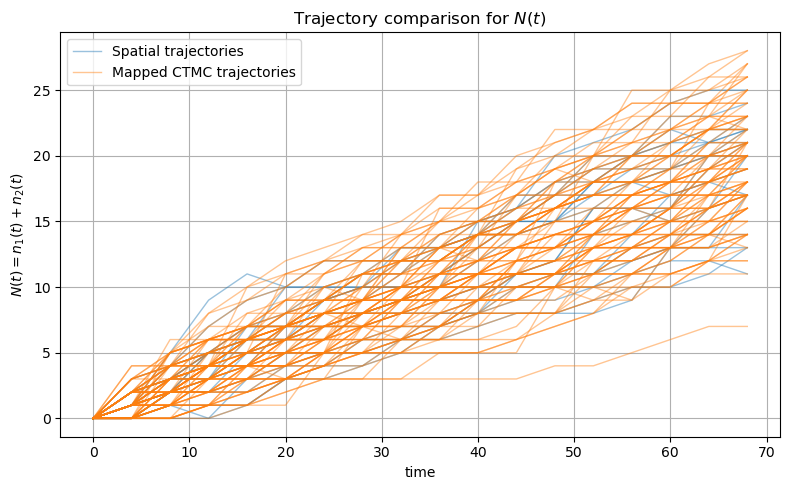

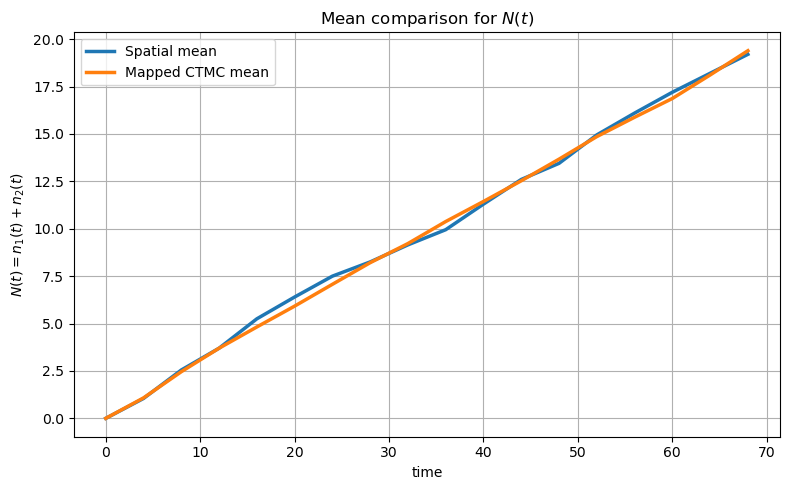

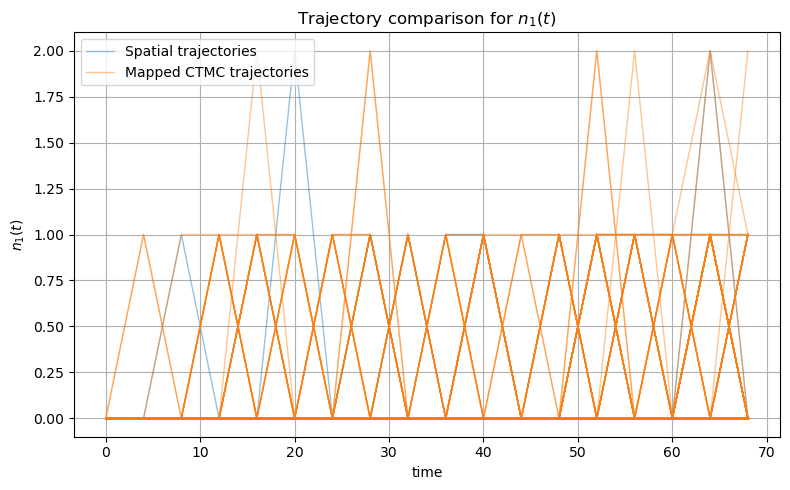

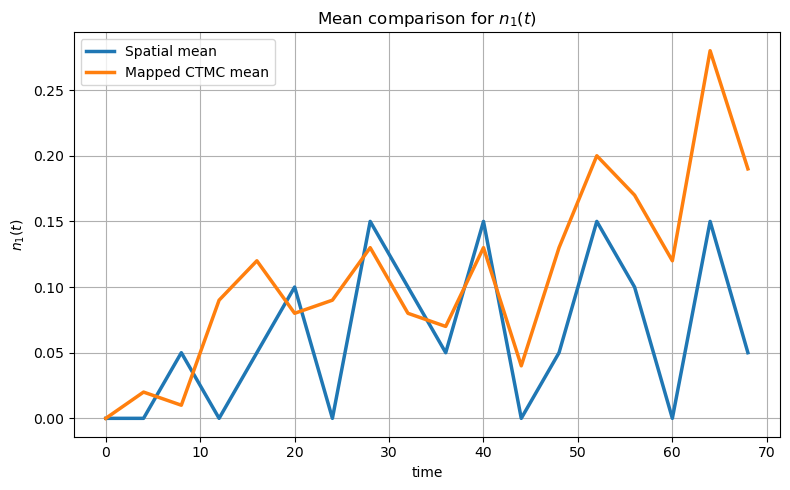

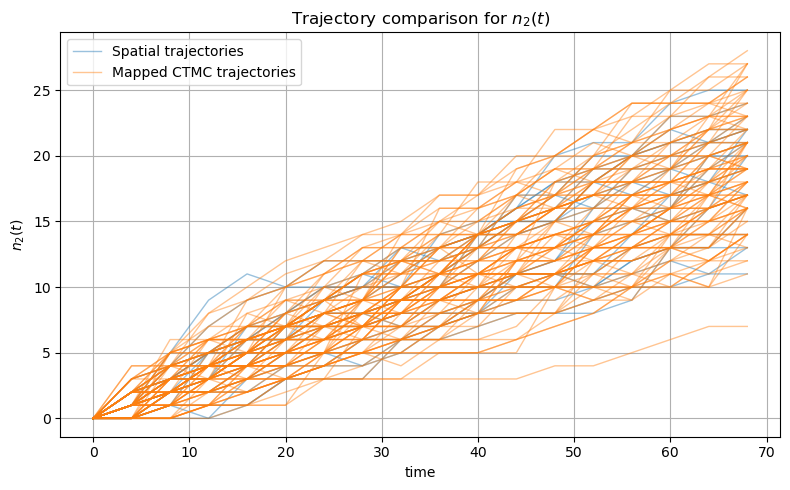

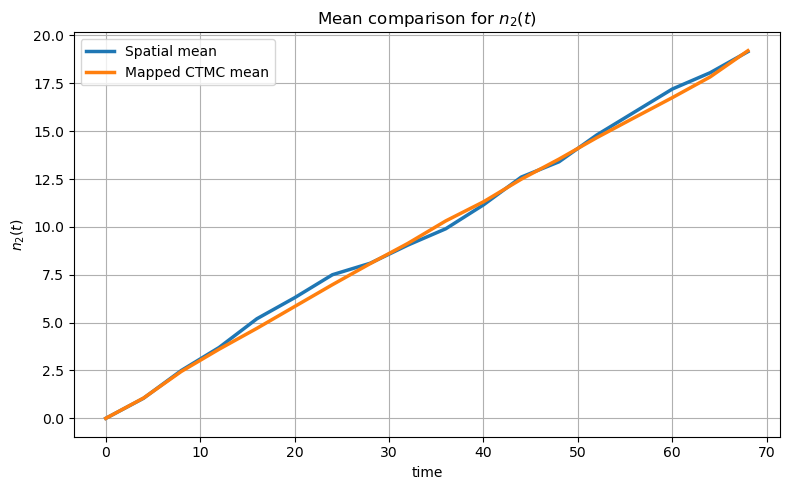

In [9]:
spatial_runs, theta_hat = estimate_ctmc_from_spatial_runs(
    initial_binding_rate_per_site=INIT_BIND,
    singly_bound_detachment_rate=K_DET_1,
    base_double_attachment_rate=K12_SITE,
    base_double_detachment_rate=K21_BASE,
    times_obs=times_obs,
    n_reps=N_SPATIAL_REPS,
    seed=1,
    verbose=True,
    **SPATIAL_KWARGS,
)

print_theta(theta_hat)

ctmc_runs = simulate_population_ctmc_many(
    theta_hat,
    times_obs,
    n_reps=N_CTMC_REPS,
    seed=2,
)

plot_n1_n2_N(
    spatial_runs,
    ctmc_runs,
    times_obs,
    max_lines=MAX_LINES_IN_TRAJECTORY_PLOT,
)



## Inspect recorded diagnostics

This cell checks the recorded rough quantities directly.


In [10]:
# Mean spatial diagnostics over all spatial runs.
spatial_N = stack_runs(spatial_runs, "N")
spatial_n1 = stack_runs(spatial_runs, "n1")
spatial_n2 = stack_runs(spatial_runs, "n2")
spatial_A = stack_runs(spatial_runs, "A_spatial")
spatial_m_sum = stack_runs(spatial_runs, "m_sum")
spatial_k10_sum = stack_runs(spatial_runs, "k10_sum")
spatial_k12_sum = stack_runs(spatial_runs, "k12_sum")
spatial_k21_sum = stack_runs(spatial_runs, "k21_sum")

print("Mean N(t):", np.round(spatial_N.mean(axis=0), 3))
print("Mean n1(t):", np.round(spatial_n1.mean(axis=0), 3))
print("Mean n2(t):", np.round(spatial_n2.mean(axis=0), 3))
print("Mean A_spatial(t):", np.round(spatial_A.mean(axis=0), 3))

# These are the numerator/denominator checks used in the map.
total_m_sum = spatial_m_sum.sum()
total_n1 = spatial_n1.sum()
total_k10_sum = spatial_k10_sum.sum()
total_k12_sum = spatial_k12_sum.sum()
total_k21_sum = spatial_k21_sum.sum()
total_n2 = spatial_n2.sum()

print("\nMapping checks:")
print("sum capped m_i / sum n1 =", total_m_sum / total_n1 if total_n1 > 0 else np.nan)
print("main capped k12 = K12_SITE * m_hat =", K12_SITE * (total_m_sum / total_n1) if total_n1 > 0 else np.nan)
print("diagnostic actual k12 = sum p.double_attachment_rate / sum n1 =", total_k12_sum / total_n1 if total_n1 > 0 else np.nan)
print("k10 direct input =", K_DET_1)
print("diagnostic sum k10_i / sum n1 =", total_k10_sum / total_n1 if total_n1 > 0 else np.nan)
print("actual k21 = sum k21_j / sum n2 =", total_k21_sum / total_n2 if total_n2 > 0 else np.nan)
print("Note: main k12 uses capped m_i <= 3. Actual p.double_attachment_rate is diagnostic only.")
print("Note: k21_j here is p.detachment_rate for each doubly bound PRC1, with no divide by 2.")

# Example: show the raw variable-length arrays at one run/time.
run_id = 0
time_id = min(5, len(times_obs) - 1)
print(f"\nExample run {run_id}, time {times_obs[time_id]}:")
print("m_values:", spatial_runs[run_id]["m_values_by_time"][time_id])
print("k12_values:", spatial_runs[run_id]["k12_values_by_time"][time_id])
print("k21_values:", spatial_runs[run_id]["k21_values_by_time"][time_id])


Mean N(t): [ 0.    1.05  2.55  3.7   5.25  6.4   7.5   8.25  9.15  9.95 11.3  12.6
 13.45 14.95 16.1  17.2  18.2  19.2 ]
Mean n1(t): [0.   0.   0.05 0.   0.05 0.1  0.   0.15 0.1  0.05 0.15 0.   0.05 0.15
 0.1  0.   0.15 0.05]
Mean n2(t): [ 0.    1.05  2.5   3.7   5.2   6.3   7.5   8.1   9.05  9.9  11.15 12.6
 13.4  14.8  16.   17.2  18.05 19.15]
Mean A_spatial(t): [626.    624.95  623.475 622.3   620.775 619.65  618.5   617.825 616.9
 616.075 614.775 613.4   612.575 611.125 609.95  608.8   607.875 606.825]

Mapping checks:
sum capped m_i / sum n1 = 2.9130434782608696
main capped k12 = K12_SITE * m_hat = 17.128695652173914
diagnostic actual k12 = sum p.double_attachment_rate / sum n1 = 24.264334303340707
k10 direct input = 0.1
diagnostic sum k10_i / sum n1 = 0.09999999999999999
actual k21 = sum k21_j / sum n2 = 0.16732988291099102
Note: main k12 uses capped m_i <= 3. Actual p.double_attachment_rate is diagnostic only.
Note: k21_j here is p.detachment_rate for each doubly bound PRC1, wit

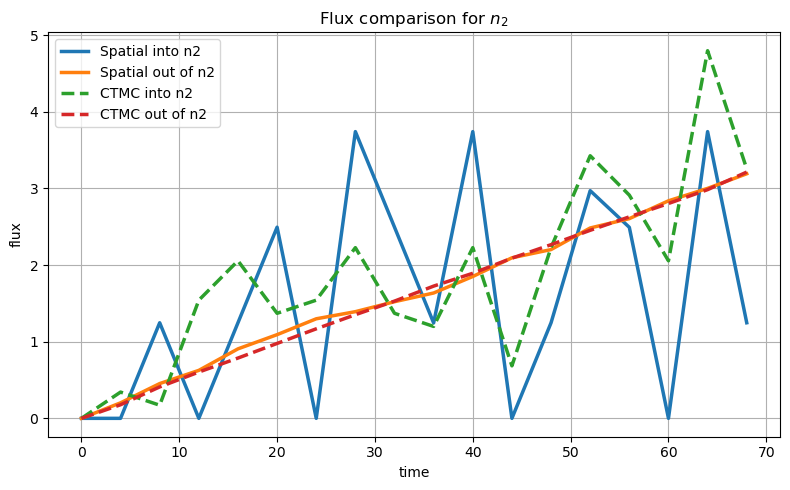

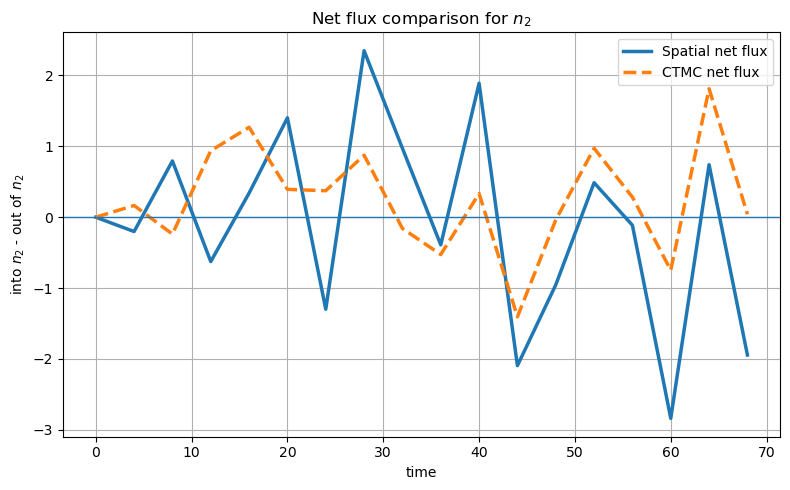

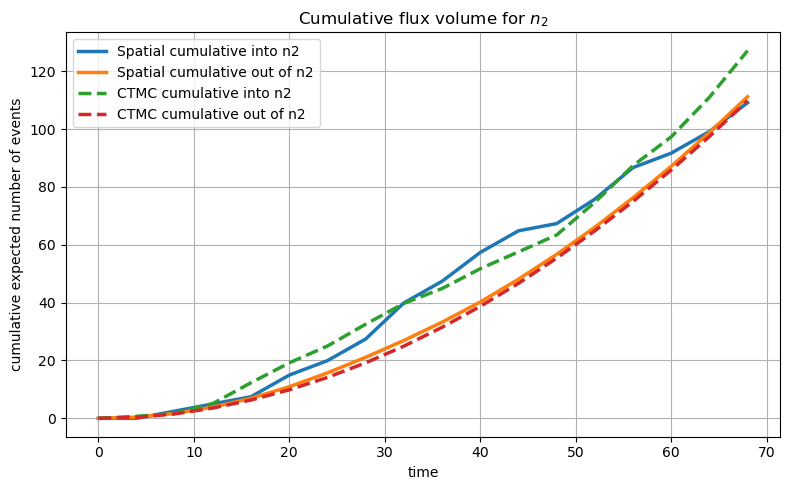

Integrated flux volumes over the observation window:
Spatial into n2 : 109.1222
Spatial out n2  : 111.1844
Spatial net     : -2.0622

CTMC into n2    : 127.0949
CTMC out n2     : 109.8086
CTMC net        : 17.2864


In [11]:
def cumulative_trapezoid_simple(y, t):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(y, dtype=float)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(t))
    return out


def plot_n2_hazard_flux(spatial_runs, ctmc_runs, theta_hat, times_obs):
    """
    Compare instantaneous expected fluxes into and out of n2.

    Spatial:
        into n2  = sum_i p_i.double_attachment_rate(t)  [diagnostic actual spatial hazard]
        out n2   = sum_j p_j.detachment_rate(t)

    CTMC:
        into n2  = k12_hat * n1(t), where k12_hat = K12_SITE * m_hat with m_i <= 3
        out n2   = k21_hat * n2(t), where k21_hat averages p_j.detachment_rate
    """
    times_obs = np.asarray(times_obs, dtype=float)

    # spatial hazard fluxes, already recorded in the new notebook
    spatial_in = stack_runs(spatial_runs, "k12_sum")   # n1 -> n2
    spatial_out = stack_runs(spatial_runs, "k21_sum")  # n2 -> n1

    # CTMC hazard fluxes
    ctmc_n1 = stack_runs(ctmc_runs, "n1")
    ctmc_n2 = stack_runs(ctmc_runs, "n2")

    ctmc_in = theta_hat["k12"] * ctmc_n1
    ctmc_out = theta_hat["k21"] * ctmc_n2

    # means
    spatial_in_mean = spatial_in.mean(axis=0)
    spatial_out_mean = spatial_out.mean(axis=0)
    ctmc_in_mean = ctmc_in.mean(axis=0)
    ctmc_out_mean = ctmc_out.mean(axis=0)

    spatial_net_mean = spatial_in_mean - spatial_out_mean
    ctmc_net_mean = ctmc_in_mean - ctmc_out_mean

    # ------------------------------------------------------------
    # Plot instantaneous fluxes
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(times_obs, spatial_in_mean, linewidth=2.5, label="Spatial into n2")
    ax.plot(times_obs, spatial_out_mean, linewidth=2.5, label="Spatial out of n2")
    ax.plot(times_obs, ctmc_in_mean, "--", linewidth=2.5, label="CTMC into n2")
    ax.plot(times_obs, ctmc_out_mean, "--", linewidth=2.5, label="CTMC out of n2")

    ax.set_xlabel("time")
    ax.set_ylabel("flux")
    ax.set_title(r"Flux comparison for $n_2$")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot net flux
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(times_obs, spatial_net_mean, linewidth=2.5, label="Spatial net flux")
    ax.plot(times_obs, ctmc_net_mean, "--", linewidth=2.5, label="CTMC net flux")
    ax.axhline(0, linewidth=1)

    ax.set_xlabel("time")
    ax.set_ylabel(r"into $n_2$ - out of $n_2$")
    ax.set_title(r"Net flux comparison for $n_2$")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot cumulative expected flux volume
    # ------------------------------------------------------------
    spatial_cum_in = cumulative_trapezoid_simple(spatial_in_mean, times_obs)
    spatial_cum_out = cumulative_trapezoid_simple(spatial_out_mean, times_obs)
    ctmc_cum_in = cumulative_trapezoid_simple(ctmc_in_mean, times_obs)
    ctmc_cum_out = cumulative_trapezoid_simple(ctmc_out_mean, times_obs)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(times_obs, spatial_cum_in, linewidth=2.5, label="Spatial cumulative into n2")
    ax.plot(times_obs, spatial_cum_out, linewidth=2.5, label="Spatial cumulative out of n2")
    ax.plot(times_obs, ctmc_cum_in, "--", linewidth=2.5, label="CTMC cumulative into n2")
    ax.plot(times_obs, ctmc_cum_out, "--", linewidth=2.5, label="CTMC cumulative out of n2")

    ax.set_xlabel("time")
    ax.set_ylabel("cumulative expected number of events")
    ax.set_title(r"Cumulative flux volume for $n_2$")
    ax.legend()
    fig.tight_layout()
    plt.show()

    print("Integrated flux volumes over the observation window:")
    print(f"Spatial into n2 : {spatial_cum_in[-1]:.4f}")
    print(f"Spatial out n2  : {spatial_cum_out[-1]:.4f}")
    print(f"Spatial net     : {spatial_cum_in[-1] - spatial_cum_out[-1]:.4f}")
    print()
    print(f"CTMC into n2    : {ctmc_cum_in[-1]:.4f}")
    print(f"CTMC out n2     : {ctmc_cum_out[-1]:.4f}")
    print(f"CTMC net        : {ctmc_cum_in[-1] - ctmc_cum_out[-1]:.4f}")


plot_n2_hazard_flux(spatial_runs, ctmc_runs, theta_hat, times_obs)

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def get_run_array(run, key):
    """Return one trajectory from a run dictionary."""
    if key in run:
        return np.asarray(run[key], dtype=float)

    # fallback: compute N if not stored
    if key == "N" and ("n1" in run) and ("n2" in run):
        return np.asarray(run["n1"], dtype=float) + np.asarray(run["n2"], dtype=float)

    raise KeyError(f"Run does not contain key '{key}'.")

def stack_runs(runs, key):
    """Stack trajectories into shape (n_runs, T)."""
    return np.asarray([get_run_array(run, key) for run in runs], dtype=float)

def print_trajectory_summary(runs, times_obs, label="runs"):
    """
    Print mean trajectory for N, n1, n2.
    Also prints the first trajectory as an example.
    """
    times_obs = np.asarray(times_obs, dtype=float)

    print("=" * 80)
    print(label)
    print("=" * 80)

    for key in ["N", "n1", "n2"]:
        X = stack_runs(runs, key)
        mean_X = X.mean(axis=0)

        print(f"\n{key}:")
        print("first trajectory:")
        print(np.round(X[0], 4))

        print("mean trajectory:")
        print(np.round(mean_X, 4))

        print("time, mean:")
        for t, val in zip(times_obs, mean_X):
            print(f"{t:6.1f}  {val:10.4f}")

def plot_trajectories_with_mean(runs, times_obs, label="runs", max_lines=30):
    """
    Plot individual trajectories plus mean trajectory for N, n1, n2.
    """
    times_obs = np.asarray(times_obs, dtype=float)

    for key in ["N", "n1", "n2"]:
        X = stack_runs(runs, key)
        mean_X = X.mean(axis=0)

        fig, ax = plt.subplots(figsize=(8, 5))

        n_lines = min(max_lines, X.shape[0])
        for i in range(n_lines):
            ax.plot(times_obs, X[i], alpha=0.25, linewidth=1)

        ax.plot(times_obs, mean_X, linewidth=3, label=f"{label} mean")

        ax.set_xlabel("time")
        ax.set_ylabel(key)
        ax.set_title(f"{label}: trajectories and mean for {key}")
        ax.legend()
        fig.tight_layout()
        plt.show()

Spatial

N:
first trajectory:
[ 0.  0.  2.  2.  5.  6.  7.  8.  9. 10. 10. 10. 10. 10. 11. 12. 12. 11.]
mean trajectory:
[ 0.    1.05  2.55  3.7   5.25  6.4   7.5   8.25  9.15  9.95 11.3  12.6
 13.45 14.95 16.1  17.2  18.2  19.2 ]
time, mean:
   0.0      0.0000
   4.0      1.0500
   8.0      2.5500
  12.0      3.7000
  16.0      5.2500
  20.0      6.4000
  24.0      7.5000
  28.0      8.2500
  32.0      9.1500
  36.0      9.9500
  40.0     11.3000
  44.0     12.6000
  48.0     13.4500
  52.0     14.9500
  56.0     16.1000
  60.0     17.2000
  64.0     18.2000
  68.0     19.2000

n1:
first trajectory:
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
mean trajectory:
[0.   0.   0.05 0.   0.05 0.1  0.   0.15 0.1  0.05 0.15 0.   0.05 0.15
 0.1  0.   0.15 0.05]
time, mean:
   0.0      0.0000
   4.0      0.0000
   8.0      0.0500
  12.0      0.0000
  16.0      0.0500
  20.0      0.1000
  24.0      0.0000
  28.0      0.1500
  32.0      0.1000
  36.0      0.0500
  40.0      0.1500
  44.

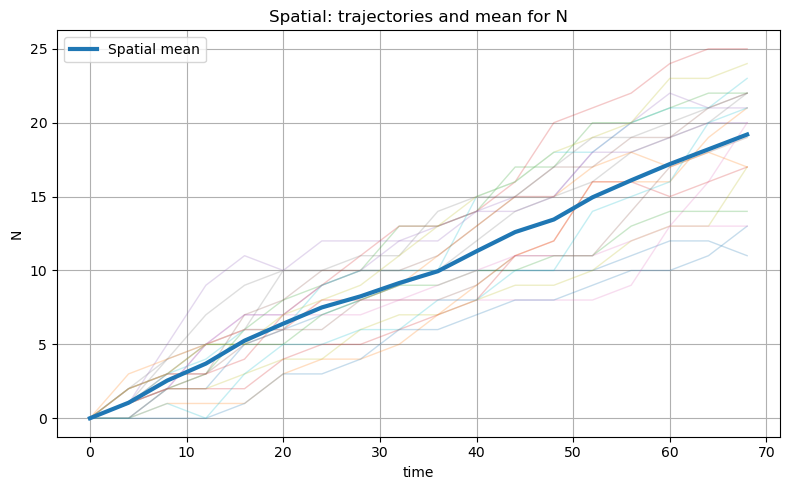

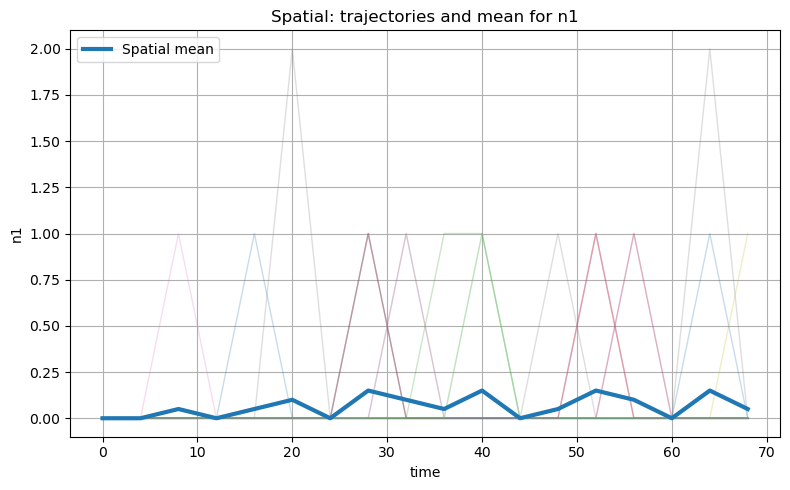

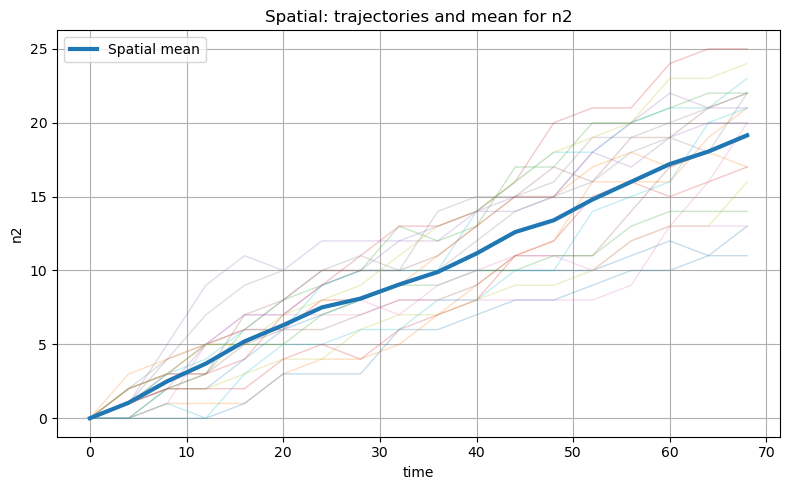

In [13]:
print_trajectory_summary(spatial_runs, times_obs, label="Spatial")
plot_trajectories_with_mean(spatial_runs, times_obs, label="Spatial")

Mapped CTMC

N:
first trajectory:
[ 0.  0.  1.  3.  5.  6.  6.  8.  9. 12. 12. 15. 18. 18. 20. 21. 22. 24.]
mean trajectory:
[ 0.    1.08  2.46  3.7   4.82  5.92  7.07  8.21  9.22 10.38 11.44 12.53
 13.67 14.86 15.88 16.87 18.11 19.39]
time, mean:
   0.0      0.0000
   4.0      1.0800
   8.0      2.4600
  12.0      3.7000
  16.0      4.8200
  20.0      5.9200
  24.0      7.0700
  28.0      8.2100
  32.0      9.2200
  36.0     10.3800
  40.0     11.4400
  44.0     12.5300
  48.0     13.6700
  52.0     14.8600
  56.0     15.8800
  60.0     16.8700
  64.0     18.1100
  68.0     19.3900

n1:
first trajectory:
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
mean trajectory:
[0.   0.02 0.01 0.09 0.12 0.08 0.09 0.13 0.08 0.07 0.13 0.04 0.13 0.2
 0.17 0.12 0.28 0.19]
time, mean:
   0.0      0.0000
   4.0      0.0200
   8.0      0.0100
  12.0      0.0900
  16.0      0.1200
  20.0      0.0800
  24.0      0.0900
  28.0      0.1300
  32.0      0.0800
  36.0      0.0700
  40.0      0.1300
 

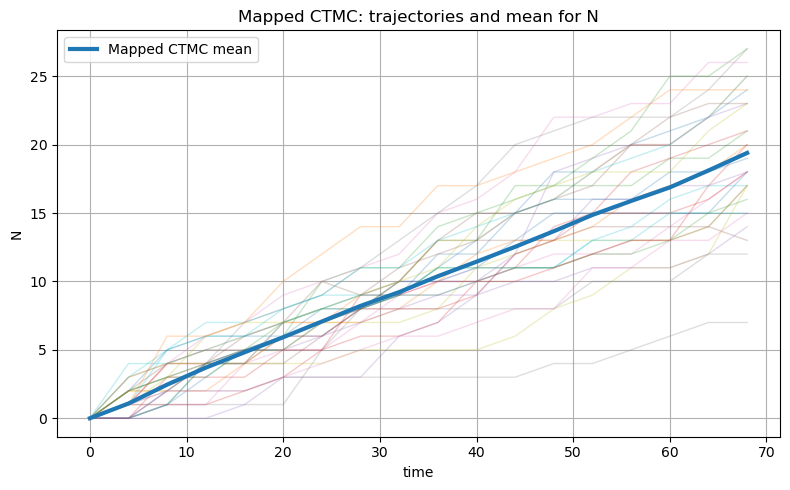

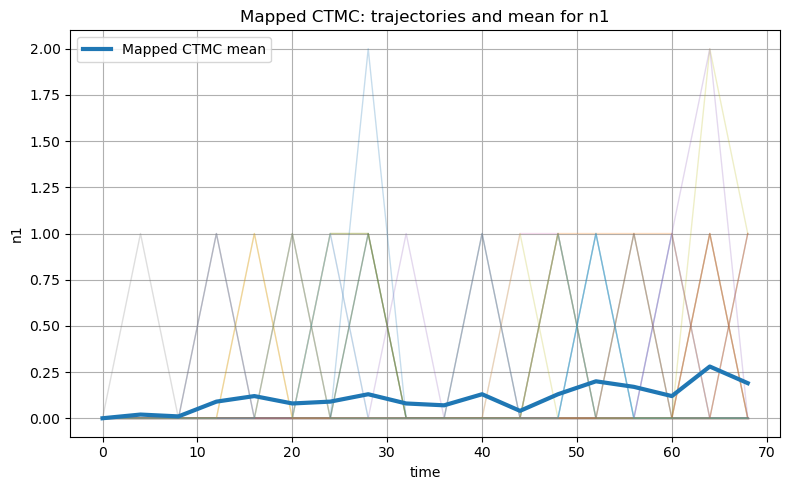

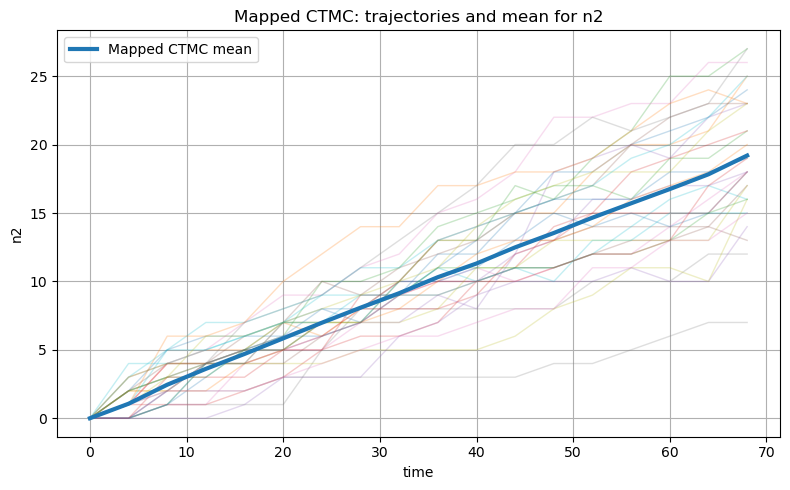

In [14]:
print_trajectory_summary(ctmc_runs, times_obs, label="Mapped CTMC")
plot_trajectories_with_mean(ctmc_runs, times_obs, label="Mapped CTMC")

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def get_run_array(run, key):
    if key in run:
        return np.asarray(run[key], dtype=float)
    if key == "N" and ("n1" in run) and ("n2" in run):
        return np.asarray(run["n1"], dtype=float) + np.asarray(run["n2"], dtype=float)
    raise KeyError(f"Run does not contain key '{key}'.")

def stack_runs(runs, key):
    return np.asarray([get_run_array(run, key) for run in runs], dtype=float)

def plot_spatial_vs_ctmc_trajectories(
    spatial_runs,
    ctmc_runs,
    times_obs,
    max_lines=30,
    spatial_label="Spatial",
    ctmc_label="Mapped CTMC",
):
    times_obs = np.asarray(times_obs, dtype=float)

    for key in ["N", "n1", "n2"]:
        spatial_X = stack_runs(spatial_runs, key)
        ctmc_X = stack_runs(ctmc_runs, key)

        spatial_mean = spatial_X.mean(axis=0)
        ctmc_mean = ctmc_X.mean(axis=0)

        fig, ax = plt.subplots(figsize=(8, 5))

        n_spatial = min(max_lines, spatial_X.shape[0])
        n_ctmc = min(max_lines, ctmc_X.shape[0])

        # individual trajectories
        for i in range(n_spatial):
            ax.plot(
                times_obs,
                spatial_X[i],
                alpha=0.20,
                linewidth=1,
            )

        for i in range(n_ctmc):
            ax.plot(
                times_obs,
                ctmc_X[i],
                alpha=0.20,
                linewidth=1,
                linestyle="--",
            )

        # mean trajectories
        ax.plot(
            times_obs,
            spatial_mean,
            linewidth=3,
            label=f"{spatial_label} mean",
        )

        ax.plot(
            times_obs,
            ctmc_mean,
            linewidth=3,
            linestyle="--",
            label=f"{ctmc_label} mean",
        )

        ax.set_xlabel("time")
        ax.set_ylabel(key)
        ax.set_title(f"{spatial_label} vs {ctmc_label}: {key}(t)")
        ax.legend()
        fig.tight_layout()
        plt.show()

        # print mean comparison
        print("=" * 80)
        print(f"{key} mean trajectory comparison")
        print("=" * 80)
        print(f"{'time':>8} {'spatial mean':>15} {'ctmc mean':>15} {'ctmc - spatial':>15}")
        for t, s, c in zip(times_obs, spatial_mean, ctmc_mean):
            print(f"{t:8.1f} {s:15.4f} {c:15.4f} {c - s:15.4f}")
        print()

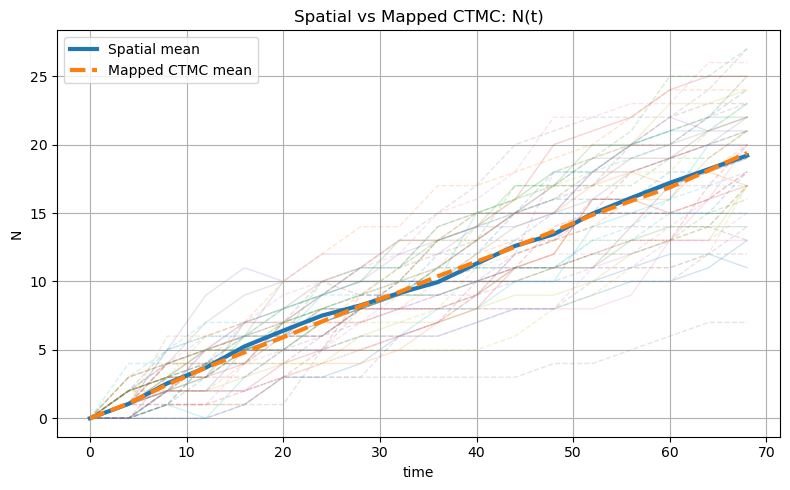

N mean trajectory comparison
    time    spatial mean       ctmc mean  ctmc - spatial
     0.0          0.0000          0.0000          0.0000
     4.0          1.0500          1.0800          0.0300
     8.0          2.5500          2.4600         -0.0900
    12.0          3.7000          3.7000          0.0000
    16.0          5.2500          4.8200         -0.4300
    20.0          6.4000          5.9200         -0.4800
    24.0          7.5000          7.0700         -0.4300
    28.0          8.2500          8.2100         -0.0400
    32.0          9.1500          9.2200          0.0700
    36.0          9.9500         10.3800          0.4300
    40.0         11.3000         11.4400          0.1400
    44.0         12.6000         12.5300         -0.0700
    48.0         13.4500         13.6700          0.2200
    52.0         14.9500         14.8600         -0.0900
    56.0         16.1000         15.8800         -0.2200
    60.0         17.2000         16.8700         -0.3300
  

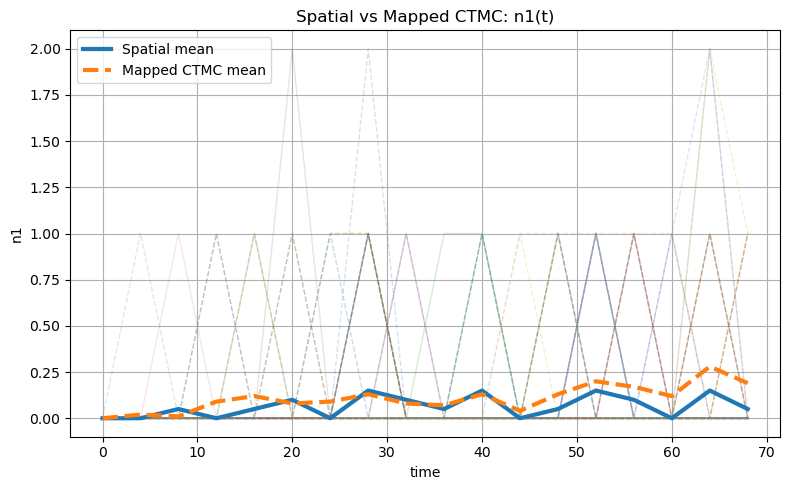

n1 mean trajectory comparison
    time    spatial mean       ctmc mean  ctmc - spatial
     0.0          0.0000          0.0000          0.0000
     4.0          0.0000          0.0200          0.0200
     8.0          0.0500          0.0100         -0.0400
    12.0          0.0000          0.0900          0.0900
    16.0          0.0500          0.1200          0.0700
    20.0          0.1000          0.0800         -0.0200
    24.0          0.0000          0.0900          0.0900
    28.0          0.1500          0.1300         -0.0200
    32.0          0.1000          0.0800         -0.0200
    36.0          0.0500          0.0700          0.0200
    40.0          0.1500          0.1300         -0.0200
    44.0          0.0000          0.0400          0.0400
    48.0          0.0500          0.1300          0.0800
    52.0          0.1500          0.2000          0.0500
    56.0          0.1000          0.1700          0.0700
    60.0          0.0000          0.1200          0.1200
 

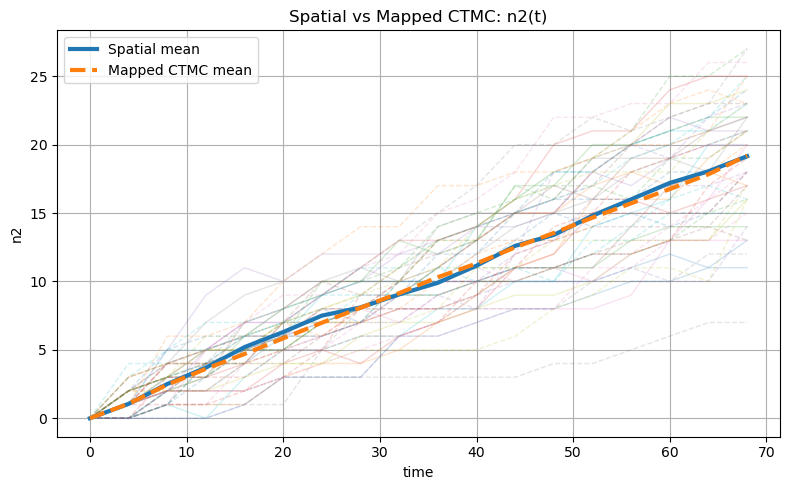

n2 mean trajectory comparison
    time    spatial mean       ctmc mean  ctmc - spatial
     0.0          0.0000          0.0000          0.0000
     4.0          1.0500          1.0600          0.0100
     8.0          2.5000          2.4500         -0.0500
    12.0          3.7000          3.6100         -0.0900
    16.0          5.2000          4.7000         -0.5000
    20.0          6.3000          5.8400         -0.4600
    24.0          7.5000          6.9800         -0.5200
    28.0          8.1000          8.0800         -0.0200
    32.0          9.0500          9.1400          0.0900
    36.0          9.9000         10.3100          0.4100
    40.0         11.1500         11.3100          0.1600
    44.0         12.6000         12.4900         -0.1100
    48.0         13.4000         13.5400          0.1400
    52.0         14.8000         14.6600         -0.1400
    56.0         16.0000         15.7100         -0.2900
    60.0         17.2000         16.7500         -0.4500
 

In [16]:
plot_spatial_vs_ctmc_trajectories(
    spatial_runs,
    ctmc_runs,
    times_obs,
    max_lines=30,
)